# PCB inspection — dual evaluation copy

The original training and export workflow is preserved below. **To evaluate existing
exports without retraining, run only the new “Dual evaluation” section at the end.**
Its first evaluation uses existing `dataset_processed/val` or `test` XML-derived
crops; its second runs the application pipeline on original full-board images.
Do not run all training/augmentation cells merely to evaluate exported models.


## CUDA

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

## Only CPU

In [ ]:
!pip install torch torchvision

In [ ]:
!pip install optuna
!pip install thop

In [ ]:
import torch
import torchvision

print("✅ PyTorch version:", torch.__version__)
print("✅ Torchvision version:", torchvision.__version__)
print("✅ CUDA acceleration available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("🛸 Active GPU Device:", torch.cuda.get_device_name(0))

In [ ]:
import os

DATASET_PATH = "dataset/PCB_DATASET"

# --- 1. File System Overview ---
print(f"\n[SECTION 1] Directory Inspection: {DATASET_PATH}")
print("-" * 40)
count = 0
for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        # if count < 10:  # Show first 10 files as examples
        #     print(f"Found: {os.path.join(root, file)}")
        #     count += 1
        print(f"Found: {os.path.join(root, file)}")
if count == 0:
    print("Warning: No files found. Please check your path.")

## Import & Parameter

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

# Ensure scikit-image is available for SSIM-NET simulation
try:
    from skimage.metrics import structural_similarity as ssim
except ImportError:
    # Fallback message to assist in setting up the environment
    raise ImportError("Please install scikit-image using: pip install scikit-image")

# Set up global parameters for comparison algorithm input requirements
TARGET_SIZE = (224, 224) # Standard input size for LPViT, ResNet, MobileNet, and AlexNet
PIXELS_PER_MM = 15.0     # Default spatial calibration factor

print("✅ Initialization complete. Target patch dimension set to:", TARGET_SIZE)

## Data Augmentation Module

In [ ]:
import os
import random
import shutil
import cv2
import datetime
import numpy as np
import xml.etree.ElementTree as ET
from pathlib import Path
from IPython.display import display, Image
from tqdm.notebook import tqdm

# ==============================================================================
# 0. CORE HELPERS
# ==============================================================================
LOG_FILE_PATH = "experiment_results_log.txt"
VISUAL_LOG_DIR = "log"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    cv2.setRNGSeed(seed)

def log_message(message):
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    formatted_msg = f"[{timestamp}] {message}"
    print(message)
    with open(LOG_FILE_PATH, "a", encoding="utf-8") as f:
        f.write(formatted_msg + "\n")

def transform_coords(xmin, ymin, xmax, ymax, h, w, jitter_range=None):
    """Calculates new coordinates by applying random BBox Jitter offset."""
    if jitter_range:
        # Ref: Huang & Wei, 2019 - Spatial offset to bounding-box coordinates
        off_x = random.randint(jitter_range[0], jitter_range[1]) * random.choice([-1, 1])
        off_y = random.randint(jitter_range[0], jitter_range[1]) * random.choice([-1, 1])
        xmin, ymin = max(0, xmin + off_x), max(0, ymin + off_y)
        xmax, ymax = min(w, xmax + off_x), min(h, ymax + off_y)
        
    return int(xmin), int(ymin), int(xmax), int(ymax)

# ==============================================================================
# 1. CORE TRANSFORMATIONS
# ==============================================================================

def add_gaussian_noise(image, sigma=20):
    """Ref: Ding et al., 2019 - Simulating industrial camera sensor noise."""
    gauss = np.random.normal(0, sigma, image.shape).astype('float32')
    return np.clip(image.astype('float32') + gauss, 0, 255).astype('uint8')

def rotate_bbox_only(image, xml_path, angle, target_classes=['Mouse_bite', 'Missing_hole']):
    """Object-level: Rotates only the defect ROI area."""
    if not (xml_path and Path(xml_path).exists()): return image
    root = ET.parse(str(xml_path)).getroot()
    rotated_image = image.copy()
    h_img, w_img = image.shape[:2]
    targets = [c.lower() for c in target_classes]
    
    for obj in root.findall('object'):
        if obj.find('name').text.lower() in targets:
            b = obj.find('bndbox')
            x1, y1, x2, y2 = int(float(b.find('xmin').text)), int(float(b.find('ymin').text)), int(float(b.find('xmax').text)), int(float(b.find('ymax').text))
            x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w_img, x2), min(h_img, y2)
            roi_w, roi_h = x2 - x1, y2 - y1
            if roi_w <= 0 or roi_h <= 0: continue
            M = cv2.getRotationMatrix2D((roi_w/2, roi_h/2), angle, 1.0)
            rotated_image[y1:y2, x1:x2] = cv2.warpAffine(image[y1:y2, x1:x2], M, (roi_w, roi_h), borderMode=cv2.BORDER_REFLECT)
    return rotated_image

# ==============================================================================
# 2. PREVIEW & VISUALIZATION (4-COLUMN GRID)
# ==============================================================================

def calculate_resized_dimensions(h, w, max_dim):
    scale = max_dim / max(h, w)
    return (int(w * scale), int(h * scale)), scale

def preview_augmentation(
    image_dir, annotation_dir,
    sigma_val=25, angle_val=12, jitter_range=(8, 8),
    preview_zoom_padding=120, seed=42
):
    set_seed(seed)
    img_path_obj, ann_path_obj = Path(image_dir), Path(annotation_dir)
    image_paths = sorted([p for p in img_path_obj.rglob('*') if p.suffix.lower() in ('.jpg', '.png')])
    
    # Try to find a target class for a better preview
    target_paths = [p for p in image_paths if p.parent.name.lower() in ['mouse_bite', 'missing_hole']]
    sample_path = random.choice(target_paths) if target_paths else random.choice(image_paths)
    xml_path = ann_path_obj / sample_path.relative_to(img_path_obj).parent / f"{sample_path.stem}.xml"

    img_bgr = cv2.imread(str(sample_path))
    h, w = img_bgr.shape[:2]

    # --- Generate Versions ---
    aug_noisy = add_gaussian_noise(img_bgr, sigma=sigma_val)
    aug_roi_rot = rotate_bbox_only(img_bgr, xml_path, angle=angle_val)

    # --- Draw Boxes for Global View ---
    dim_g, scale_g = calculate_resized_dimensions(h, w, max_dim=500)
    
    def get_global(src, jitter=None):
        canvas = cv2.resize(src, dim_g)
        root = ET.parse(str(xml_path)).getroot()
        for obj in root.findall('object'):
            b = obj.find('bndbox')
            nx1, ny1, nx2, ny2 = transform_coords(float(b.find('xmin').text), float(b.find('ymin').text), 
                                                 float(b.find('xmax').text), float(b.find('ymax').text), 
                                                 h, w, jitter_range=jitter)
            cv2.rectangle(canvas, (int(nx1*scale_g), int(ny1*scale_g)), (int(nx2*scale_g), int(ny2*scale_g)), (0,255,0), 2)
        return canvas

    g_orig = get_global(img_bgr)
    g_noise = get_global(aug_noisy)
    g_jitter = get_global(img_bgr, jitter=jitter_range)
    g_roi = get_global(aug_roi_rot)

    # --- Zoomed Close-up View ---
    root = ET.parse(str(xml_path)).getroot()
    b = root.find('object').find('bndbox')
    ox1, oy1, ox2, oy2 = float(b.find('xmin').text), float(b.find('ymin').text), float(b.find('xmax').text), float(b.find('ymax').text)

    def get_zoom(src, jitter=None):
        zx1, zy1, zx2, zy2 = transform_coords(ox1, oy1, ox2, oy2, h, w, jitter)
        cx1, cy1 = max(0, zx1-preview_zoom_padding), max(0, zy1-preview_zoom_padding)
        cx2, cy2 = min(w, zx2+preview_zoom_padding), min(h, zy2+preview_zoom_padding)
        crop = src[int(cy1):int(cy2), int(cx1):int(cx2)].copy()
        rx1, ry1, rx2, ry2 = zx1-cx1, zy1-cy1, zx2-cx1, zy2-cy1
        cv2.rectangle(crop, (int(rx1), int(ry1)), (int(rx2), int(ry2)), (0, 255, 0), 3)
        return cv2.resize(crop, (400, 400))

    z_orig = get_zoom(img_bgr)
    z_noise = get_zoom(aug_noisy)
    z_jitter = get_zoom(img_bgr, jitter=jitter_range)
    z_roi = get_zoom(aug_roi_rot)

    # Combine grids
    grid_g = np.hstack([g_orig, g_noise, g_jitter, g_roi])
    labels = ["Original", "Gaussian Noise", "BBox Jitter", "ROI Rotated"]
    for i, txt in enumerate(labels): cv2.putText(grid_g, txt, (10 + i*dim_g[0], 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)
    
    grid_z = np.hstack([z_orig, z_noise, z_jitter, z_roi])
    
    display(Image(data=cv2.imencode('.jpg', grid_g)[1].tobytes()))
    display(Image(data=cv2.imencode('.jpg', grid_z)[1].tobytes()))

# ==============================================================================
# 3. BATCH AUGMENTATION
# ==============================================================================

def augment_dataset(
    image_dir, 
    annotation_dir, 
    output_img_dir, 
    output_xml_dir, 
    sample_ratio=0.8,
    sigma_range=(15, 25), 
    angle_range=(-15, 15),
    jitter_range=(5, 10),      # Ref: Huang & Wei (2019)
    seed=42
):
    """
    Performs the full industrial pipeline: 
    Augment (Rotation/Noise) -> Preprocess (Bilateral/CLAHE) -> Save with Jittered XML.
    """
    if seed is not None:
        set_seed(seed)

    img_path_obj = Path(image_dir)
    ann_path_obj = Path(annotation_dir)
    out_img_obj = Path(output_img_dir)
    out_xml_obj = Path(output_xml_dir)

    # Gather image list
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    image_paths = sorted([p for p in img_path_obj.rglob('*') if p.suffix.lower() in valid_extensions])

    if not image_paths:
        log_message(f"⚠️ No images found in: {image_dir}")
        return

    num_to_augment = int(len(image_paths) * sample_ratio)
    selected_images = random.sample(image_paths, num_to_augment)

    log_message("\n" + "=" * 65)
    log_message("🚀 DATA AUGMENTATION & PREPROCESSING STARTED")
    log_message(f"   -> Sequence: Augment -> Preprocess (Bilateral + CLAHE)")
    log_message(f"   -> Target: {num_to_augment} images ({sample_ratio*100}%)")
    log_message("=" * 65)

    for img_path in tqdm(selected_images, desc="Processing"):
        rel_path = img_path.relative_to(img_path_obj)
        xml_path = ann_path_obj / rel_path.parent / f"{img_path.stem}.xml"

        img = cv2.imread(str(img_path))
        if img is None: continue
        h, w = img.shape[:2]

        # --- STEP 1: AUGMENTATION (ROI ROTATION) ---
        aug_img = img.copy()
        is_target = rel_path.parent.name.lower() in ["missing_hole", "mouse_bite"]
        if is_target:
            angle = random.uniform(*angle_range)
            aug_img = rotate_bbox_only(aug_img, xml_path, angle=angle)

        # --- STEP 2: AUGMENTATION (GAUSSIAN NOISE) ---
        sigma = random.randint(*sigma_range)
        aug_img = add_gaussian_noise(aug_img, sigma=sigma)

        # --- STEP 3: PREPROCESSING (BILATERAL + CLAHE) ---
        # We clean the augmented/noisy image before saving
        final_img = preprocess_pcb_image(aug_img)

        # --- STEP 4: PREPARE PATHS & NAMES ---
        save_name = f"{img_path.stem}_aug_final"
        target_img_folder = out_img_obj / rel_path.parent
        target_xml_folder = out_xml_obj / rel_path.parent
        target_img_folder.mkdir(parents=True, exist_ok=True)
        target_xml_folder.mkdir(parents=True, exist_ok=True)

        # Save Image
        cv2.imwrite(str(target_img_folder / f"{save_name}{img_path.suffix}"), final_img)

        # --- STEP 5: SAVE XML WITH BBOX JITTER ---
        if xml_path.exists():
            tree = ET.parse(xml_path)
            root = tree.getroot()
            for obj in root.findall('object'):
                b = obj.find('bndbox')
                # Apply 5-10px spatial offset (Huang & Wei, 2019)
                nx1, ny1, nx2, ny2 = transform_coords(
                    float(b.find('xmin').text), float(b.find('ymin').text),
                    float(b.find('xmax').text), float(b.find('ymax').text),
                    h, w, jitter_range=jitter_range
                )
                b.find('xmin').text, b.find('ymin').text = str(nx1), str(ny1)
                b.find('xmax').text, b.find('ymax').text = str(nx2), str(ny2)
            tree.write(target_xml_folder / f"{save_name}.xml")

    log_message(f"✅ SUCCESSFULLY GENERATED {num_to_augment} PREPROCESSED SAMPLES.")


## Preview Augmentation

In [ ]:
# ==============================================================================
# EXECUTION
# ==============================================================================
preview_augmentation(
    image_dir='dataset/PCB_DATASET/images',
    annotation_dir='dataset/PCB_DATASET/Annotations',
    sigma_val=25,
    angle_val=12,
    jitter_range=(5, 10), 
    seed=42
)

## Preprocessing Module

In [ ]:
# ==============================================================================
# CELL 2: PARAMETER PREVIEW & PIPELINE VISUALIZATION (AUGMENT -> PREPROCESS)
# ==============================================================================

def preview_pipeline(
    image_dir, 
    annotation_dir, 
    sigma_range=(15, 25), 
    angle_range=(-15, 15), 
    jitter_range=(5, 10),
    preview_zoom_padding=120,
    seed=42
):
    """
    Visualizes the Industrial Sequence: 
    Raw -> Augmentation (Noise/Rotation) -> Preprocessing (Clean/Enhance)
    """
    if seed is not None:
        set_seed(seed)

    img_path_obj, ann_path_obj = Path(image_dir), Path(annotation_dir)
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp')
    image_paths = sorted([p for p in img_path_obj.rglob('*') if p.suffix.lower() in valid_exts])
    
    if not image_paths:
        log_message(f"⚠️ No images found in: {image_dir}")
        return
        
    target_sample_paths = [p for p in image_paths if p.parent.name.lower() in ['mouse_bite', 'missing_hole']]
    sample_path = random.choice(target_sample_paths) if target_sample_paths else random.choice(image_paths)
    xml_path = ann_path_obj / sample_path.relative_to(img_path_obj).parent / f"{sample_path.stem}.xml"
    
    img_bgr = cv2.imread(str(sample_path))
    if img_bgr is None: return
    h, w = img_bgr.shape[:2]

    # --- STEP 1: AUGMENTATION FIRST ---
    mid_sigma = sum(sigma_range) // 2
    mid_angle = sum(angle_range) / 2.0 or 12.0
    
    # Create the Augmented Raw Image (simulating a noisy capture)
    aug_raw = img_bgr.copy()
    class_name_lower = sample_path.parent.name.lower()
    if class_name_lower in ["missing_hole", "mouse_bite"]:
        aug_raw = rotate_bbox_only(aug_raw, xml_path, angle=mid_angle)
    aug_raw = add_gaussian_noise(aug_raw, sigma=mid_sigma)
    
    # --- STEP 2: PREPROCESS THE RESULTS ---
    # Col 2: Preprocess the original
    prep_original = preprocess_pcb_image(img_bgr)
    
    # Col 4: Preprocess the augmented/noisy version (This is what the model eventually sees)
    prep_aug = preprocess_pcb_image(aug_raw)

    # --- STEP 3: COORDINATE TRANSFORMATION (BBox Jitter) ---
    def get_preview_coords(xml_p, jitter=None):
        if not xml_p.exists(): return []
        root = ET.parse(xml_p).getroot()
        coords = []
        for obj in root.findall('object'):
            b = obj.find('bndbox')
            nx1, ny1, nx2, ny2 = transform_coords(
                float(b.find('xmin').text), float(b.find('ymin').text),
                float(b.find('xmax').text), float(b.find('ymax').text),
                h, w, jitter_range=jitter
            )
            coords.append((nx1, ny1, nx2, ny2))
        return coords

    coords_orig = get_preview_coords(xml_path, jitter=None)
    coords_jitter = get_preview_coords(xml_path, jitter=jitter_range)

    # --- STEP 4: GRID RENDERING ---
    dim_g, scale_g = calculate_resized_dimensions(h, w, max_dim=500)
    
    def draw_global(base_img, coord_list):
        canvas = cv2.resize(base_img, dim_g)
        for (x1, y1, x2, y2) in coord_list:
            cv2.rectangle(canvas, (int(x1*scale_g), int(y1*scale_g)), (int(x2*scale_g), int(y2*scale_g)), (0, 255, 0), 2)
        return canvas

    p1 = draw_global(img_bgr, coords_orig)      # Raw
    p2 = draw_global(prep_original, coords_orig) # Raw -> Prep
    p3 = draw_global(aug_raw, coords_jitter)    # Raw -> Aug
    p4 = draw_global(prep_aug, coords_jitter)   # Raw -> Aug -> Prep

    # --- STEP 5: ZOOM RENDERING ---
    if coords_orig:
        ox1, oy1, ox2, oy2 = coords_orig[0]
        jx1, jy1, jx2, jy2 = coords_jitter[0]
        
        def get_zoom_patch(src, x1, y1, x2, y2):
            cx1, cy1 = max(0, x1-preview_zoom_padding), max(0, y1-preview_zoom_padding)
            cx2, cy2 = min(w, x2+preview_zoom_padding), min(h, y2+preview_zoom_padding)
            crop = src[int(cy1):int(cy2), int(cx1):int(cx2)]
            
            # Standardization: Letterboxing to 400x400
            h_c, w_c = crop.shape[:2]
            scale = min(400/w_c, 400/h_c)
            nw, nh = int(w_c * scale), int(h_c * scale)
            resized = cv2.resize(crop, (nw, nh))
            canvas = np.zeros((400, 400, 3), dtype=np.uint8)
            dx, dy = (400-nw)//2, (400-nh)//2
            canvas[dy:dy+nh, dx:dx+nw] = resized
            
            rx1 = (x1 - cx1) * scale + dx
            ry1 = (y1 - cy1) * scale + dy
            rx2 = (x2 - cx1) * scale + dx
            ry2 = (y2 - cy1) * scale + dy
            cv2.rectangle(canvas, (int(rx1), int(ry1)), (int(rx2), int(ry2)), (0, 255, 0), 3)
            return canvas

        z1 = get_zoom_patch(img_bgr, ox1, oy1, ox2, oy2)
        z2 = get_zoom_patch(prep_original, ox1, oy1, ox2, oy2)
        z3 = get_zoom_patch(aug_raw, jx1, jy1, jx2, jy2)
        z4 = get_zoom_patch(prep_aug, jx1, jy1, jx2, jy2)
    else:
        z1 = z2 = z3 = z4 = np.zeros((400, 400, 3), dtype=np.uint8)

    grid_g = np.hstack([p1, p2, p3, p4])
    grid_z = np.hstack([z1, z2, z3, z4])
    
    titles = ["1. Raw", "2. Raw -> Prep", "3. Raw -> Aug", "4. Raw -> Aug -> Prep"]
    for i, txt in enumerate(titles):
        cv2.putText(grid_g, txt, (10 + i*dim_g[0], 30), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 2)

    log_message(f"ℹ️ Previewing Logic: Augmentation applied before Preprocessing (Seed: {seed})")
    log_message(f"   -> Preprocessing: Bilateral Filter & CLAHE only.")
    
    display(Image(data=cv2.imencode('.jpg', grid_g)[1].tobytes()))
    display(Image(data=cv2.imencode('.jpg', grid_z)[1].tobytes()))

# --- EXECUTION ---
preview_pipeline(
    image_dir='dataset/PCB_DATASET/images',
    annotation_dir='dataset/PCB_DATASET/Annotations',
    sigma_range=(15, 25),
    angle_range=(-15, 15),
    jitter_range=(5, 10),
    seed=42
)

## 1. Perform Augmentation

In [ ]:
# ==============================================================================
# PERFORM BATCH AUGMENTATION & PREPROCESSING
# ==============================================================================

def reset_augmented_data(*folder_paths):
    """
    Recursively deletes specified folders to reset workspace with logging.
    Ensures a clean slate before generating new augmented data.
    """
    deleted = False
    for folder in folder_paths:
        path_obj = Path(folder)
        if path_obj.exists():
            shutil.rmtree(path_obj)
            log_message(f"🗑️ Removed directory tree: {path_obj}")
            deleted = True
            
        path_obj.mkdir(parents=True, exist_ok=True)
        
    if not deleted:
        log_message("⚠️ Specified directories did not exist. Created new empty folders.")

# 1. Lock global seeds before resetting and generating
set_seed(42)

# 2. Reset and clear old folders to ensure a clean slate
# Uses the helper function from your previous workspace
reset_augmented_data(
    'dataset/PCB_DATASET/augmented_images',
    'dataset/PCB_DATASET/augmented_annotations'
)

# 3. Run batch generation 
# Note: Exposure (Gamma) and Brightness (Beta) are removed as requested.
# The focus is now on Noise, ROI Rotation, and BBox Jitter followed by Prep.
augment_dataset(
    image_dir='dataset/PCB_DATASET/images',
    annotation_dir='dataset/PCB_DATASET/Annotations',
    output_img_dir='dataset/PCB_DATASET/augmented_images',
    output_xml_dir='dataset/PCB_DATASET/augmented_annotations',
    sample_ratio=0.8,               # Process 80% of the dataset
    sigma_range=(15, 25),           # Industrial sensor noise
    angle_range=(-15, 15),          # Local defect rotation
    jitter_range=(5, 10),           # BBox coordinate offset (Ref: Huang & Wei)
    seed=42                         # Guarantees reproducible results
)

## 2. Generate Unified Dataset with structural board id segregation 

In [ ]:
# ==============================================================================
# CELL 4: GENERATE UNIFIED DATASET WITH STRUCTURAL BOARD ID SEGREGATION
# ==============================================================================
# --- 1. Global Parameters ---
DATASET_PATH = "dataset/PCB_DATASET"
OUTPUT_DIR = "dataset_processed"

# Strict non-overlapping partitioning by Board ID
TRAIN_BOARDS = ["01", "04", "05", "06", "07", "08"]  
VAL_BOARDS   = ["09", "10"]                        
TEST_BOARDS  = ["11", "12"]                        

CLASS_NAMES = ["Missing_hole", "Mouse_bite", "Open_circuit", "Short", "Spur", "Spurious_copper"]

# Standard & Augmented data sources
DATA_SOURCES = [
    {"name": "original", "ann_dir": "Annotations", "img_dir": "images"},
    {"name": "augmented", "ann_dir": "augmented_annotations", "img_dir": "augmented_images"}
]

def generate_unified_dataset():
    log_message("⏳ Starting unified standard preprocessing & tri-stage dataset generation...")
    log_message(f"   -> Train: Boards {TRAIN_BOARDS} (Original + Aug)")
    log_message(f"   -> Val:   Boards {VAL_BOARDS} (Original Only)")
    log_message(f"   -> Test:  Boards {TEST_BOARDS} (Original Only)")
    print("-" * 65)

    # Initialize directory splits
    if os.path.exists(OUTPUT_DIR):
        shutil.rmtree(OUTPUT_DIR)

    for split in ["train", "val", "test"]:
        for cls in CLASS_NAMES:
            os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

    # Initialize tools from earlier cells
    calibrator = PCBCalibrator(pixels_per_mm=PIXELS_PER_MM)
    total_patches = 0
    
    for cls in CLASS_NAMES:
        split_counts = {"train": 0, "val": 0, "test": 0}
        
        for src in DATA_SOURCES:
            ann_path = os.path.join(DATASET_PATH, src["ann_dir"], cls)
            img_path = os.path.join(DATASET_PATH, src["img_dir"], cls)
            
            if not os.path.exists(ann_path): continue
                
            xml_files = sorted([f for f in os.listdir(ann_path) if f.endswith('.xml')])
            
            for xml_file in xml_files:
                # 1. Extract Board ID (e.g., "01" from "01_missing_hole_01.xml")
                board_id = xml_file.split('_')[0]
                
                # 2. Strict Leakage Prevention Logic
                target_split = None
                if board_id in TRAIN_BOARDS:
                    target_split = "train"
                elif board_id in VAL_BOARDS and src["name"] == "original":
                    target_split = "val"
                elif board_id in TEST_BOARDS and src["name"] == "original":
                    target_split = "test"
                
                if target_split is None: continue

                # 3. Path Management
                img_ext = ".jpg" # Default extension
                target_img_path = os.path.join(img_path, xml_file.replace('.xml', img_ext))
                if not os.path.exists(target_img_path): continue
                
                # 4. Image Loading & Calibration (Ref: Huang & Wei)
                raw_target = cv2.imread(target_img_path)
                if raw_target is None: continue
                
                # [Optional Alignment] 
                # Find template to align (e.g., dataset/PCB_DATASET/images/01.jpg)
                template_path = os.path.join(DATASET_PATH, "images", f"{board_id}.jpg")
                if os.path.exists(template_path):
                    ref_img = cv2.imread(template_path)
                    # Align the target image to the standard template before cropping
                    raw_target = calibrator.rectify_and_align(raw_target, ref_img)
                
                # 5. Unified Preprocessing (Bilateral + CLAHE)
                # Calling the shared function from Cell 1
                prep_target = preprocess_pcb_image(raw_target)
                
                # 6. Extract Standardized Patches (With Padding, NO stretching)
                xml_full_path = os.path.join(ann_path, xml_file)
                patches = extract_ground_truth_patches(prep_target, xml_full_path, target_size=TARGET_SIZE)
                
                # 7. Save Patches to Disk
                for p_idx, patch_data in enumerate(patches):
                    patch_img = patch_data["patch"]
                    save_name = f"{xml_file.replace('.xml', '')}_p{p_idx}.jpg"
                    save_path = os.path.join(OUTPUT_DIR, target_split, cls, save_name)
                    
                    cv2.imwrite(save_path, patch_img)
                    total_patches += 1
                    split_counts[target_split] += 1
                    
        log_message(f"✅ Class '{cls:<16}' -> Train:{split_counts['train']:<4} | Val:{split_counts['val']:<3} | Test:{split_counts['test']:<3}")
        
    print("-" * 65)
    log_message(f"🎉 Success! Generated {total_patches} unified patches in '{OUTPUT_DIR}'.")

generate_unified_dataset()

## Load Preprocessed Dataset

In [ ]:
# ==============================================================================
# PHASE 2: DATALOADERS CREATION (OPTIMIZED FOR PCB DEFECTS)
# ==============================================================================
import os
import torch
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Define Transforms ---
# We keep online augmentation light because Offline augmentation is already done.
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=10), # Reduced slightly to avoid excessive warping
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Micro-adjustments
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 2. Load Datasets ---
PROCESSED_DIR = "dataset_processed"
train_dataset = datasets.ImageFolder(root=os.path.join(PROCESSED_DIR, "train"), transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=os.path.join(PROCESSED_DIR, "val"),   transform=eval_transforms)
test_dataset  = datasets.ImageFolder(root=os.path.join(PROCESSED_DIR, "test"),  transform=eval_transforms)

# --- 3. Compute Sampling Weights for Better Class Balance ---
targets = train_dataset.targets
class_count = np.unique(targets, return_counts=True)[1]
# Weight for each SAMPLE in the training set
weight = 1. / class_count
samples_weight = torch.from_numpy(weight[targets])
sampler = WeightedRandomSampler(samples_weight.type('torch.DoubleTensor'), len(samples_weight))

# --- 4. Instantiate DataLoaders ---
BATCH_SIZE = 32
# Use sampler for train_loader instead of shuffle=True
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# --- 5. Verify & Compute Loss Weights (Backup Strategy) ---
print("📊 Dataset Statistics:")
print("-" * 65)
total = len(train_dataset)
class_weights = []
for idx, class_name in enumerate(train_dataset.classes):
    count = (np.array(targets) == idx).sum()
    print(f"ID {idx} | {class_name:<16} | Count: {count:<5} | {100*count/total:.1f}%")
    class_weights.append(total / (len(train_dataset.classes) * count))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

# --- 6. VISUALIZATION CHECK ---
def show_batch(dl):
    img_batch, label_batch = next(iter(dl))
    plt.figure(figsize=(12, 5))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        # Un-normalize for visualization
        img = img_batch[i].numpy().transpose((1, 2, 0))
        img = np.clip(img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
        plt.imshow(img)
        plt.title(train_dataset.classes[label_batch[i]])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

log_message(f"✅ DataLoaders Ready. Device: {device}")
show_batch(train_loader)

In [ ]:
## Detection & Patch Extraction for the 4 Algorithm

In [ ]:
# ==============================================================================
# PHASE 3 & 6: BASELINE MODELS, HPO, AND TUNED MODEL INITIALIZATION
# ==============================================================================

import datetime
import random

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

from sklearn.metrics import average_precision_score

try:
    import optuna
except ImportError:
    raise ImportError("Please install Optuna first: pip install optuna")


# ------------------------------------------------------------------------------
# Logging
# ------------------------------------------------------------------------------

def log_message(message):
    """Print a message and append it to the persistent experiment log."""
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    formatted_message = f"[{timestamp}] {message}"

    print(message)

    with open(LOG_FILE_PATH, "a", encoding="utf-8") as log_file:
        log_file.write(formatted_message + "\n")


with open(LOG_FILE_PATH, "a", encoding="utf-8") as log_file:
    log_file.write("\n" + "=" * 80 + "\n")
    log_file.write(
        f"BASELINE AND HPO SESSION STARTED AT {datetime.datetime.now()}\n"
    )
    log_file.write("=" * 80 + "\n")


# ------------------------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------------------------

def set_seed(seed=42):
    """Set random seeds for reproducible experiments."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)


# ------------------------------------------------------------------------------
# Shared configuration
# ------------------------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 6

GLOBAL_SHARED_PARAMS = {
    "lr": 5e-5,
    "optimizer": optim.AdamW,
    "epochs_per_trial": 3,
    "label_smoothing": 0.1,
    "batch_size": BATCH_SIZE,
}


# ------------------------------------------------------------------------------
# Lightweight Vision Transformer
# ------------------------------------------------------------------------------

class LightweightViT(nn.Module):
    """A lightweight Vision Transformer for PCB defect classification."""

    def __init__(
        self,
        num_classes=NUM_CLASSES,
        img_size=224,
        patch_size=16,
        embed_dim=192,
        depth=6,
        num_heads=3,
        mlp_ratio=2.0,
    ):
        super().__init__()

        num_patches = (img_size // patch_size) ** 2

        self.patch_embed = nn.Conv2d(
            in_channels=3,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches + 1, embed_dim)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            activation="gelu",
            batch_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth,
        )

        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x).flatten(2).transpose(1, 2)

        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embed
        x = self.transformer(x)

        return self.head(x[:, 0])


# ------------------------------------------------------------------------------
# CNN model factories
# ------------------------------------------------------------------------------

def get_cs_resnet(num_classes=NUM_CLASSES, dropout_p=0.0):
    """Create a ResNet-18 with configurable classifier dropout."""
    model = models.resnet18(weights=None)

    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(in_features, num_classes),
    )

    return model


def get_mobilenet_v3(num_classes=NUM_CLASSES, dropout_p=0.2):
    """Create a MobileNetV3-Small with configurable classifier dropout."""
    model = models.mobilenet_v3_small(weights=None)

    model.classifier[2].p = dropout_p
    model.classifier[3] = nn.Linear(
        model.classifier[3].in_features,
        num_classes,
    )

    return model


def get_alexnet(num_classes=NUM_CLASSES, dropout_p=0.5):
    """Create an AlexNet with configurable classifier dropout."""
    model = models.alexnet(weights=None)

    model.classifier[2].p = dropout_p
    model.classifier[5].p = dropout_p
    model.classifier[6] = nn.Linear(
        model.classifier[6].in_features,
        num_classes,
    )

    return model


# ------------------------------------------------------------------------------
# Model builder
# ------------------------------------------------------------------------------

def build_model(model_name, params=None):
    """Build a model using default or HPO-selected model-specific parameters."""
    params = params or {}

    if "LPViT" in model_name:
        return LightweightViT(
            num_classes=NUM_CLASSES,
            num_heads=params.get("num_heads", 3),
            mlp_ratio=params.get("mlp_ratio", 2.0),
        )

    if "CS-ResNet" in model_name:
        return get_cs_resnet(
            num_classes=NUM_CLASSES,
            dropout_p=params.get("dropout_p", 0.0),
        )

    if "MobileNetV3" in model_name:
        return get_mobilenet_v3(
            num_classes=NUM_CLASSES,
            dropout_p=params.get("dropout_p", 0.2),
        )

    if "AlexNet" in model_name:
        return get_alexnet(
            num_classes=NUM_CLASSES,
            dropout_p=params.get("dropout_p", 0.5),
        )

    raise ValueError(f"Unsupported model name: {model_name}")


# ------------------------------------------------------------------------------
# Hyperparameter optimization
# ------------------------------------------------------------------------------

def tuning_objective(trial, model_name):
    """Train one trial and return its best validation macro mAP."""
    set_seed(42)

    if "LPViT" in model_name:
        params = {
            "num_heads": trial.suggest_categorical(
                "num_heads",
                [3, 4, 6],
            ),
            "mlp_ratio": trial.suggest_categorical(
                "mlp_ratio",
                [2.0, 4.0],
            ),
        }

    elif "CS-ResNet" in model_name:
        params = {
            "dropout_p": trial.suggest_float(
                "dropout_p",
                0.0,
                0.5,
            ),
        }

    elif "MobileNetV3" in model_name:
        params = {
            "dropout_p": trial.suggest_float(
                "dropout_p",
                0.0,
                0.5,
            ),
        }

    elif "AlexNet" in model_name:
        params = {
            "dropout_p": trial.suggest_float(
                "dropout_p",
                0.2,
                0.5,
            ),
        }

    else:
        raise ValueError(f"Unsupported HPO model: {model_name}")

    model = build_model(
        model_name=model_name,
        params=params,
    ).to(device)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor,
        label_smoothing=GLOBAL_SHARED_PARAMS["label_smoothing"],
    )

    optimizer = GLOBAL_SHARED_PARAMS["optimizer"](
        model.parameters(),
        lr=GLOBAL_SHARED_PARAMS["lr"],
    )

    best_map = 0.0

    for _ in range(GLOBAL_SHARED_PARAMS["epochs_per_trial"]):
        model.train()

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

        model.eval()
        all_labels = []
        all_probabilities = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)

                outputs = model(images)
                probabilities = torch.softmax(outputs, dim=1)

                all_labels.extend(labels.numpy())
                all_probabilities.extend(probabilities.cpu().numpy())

        one_hot_labels = np.eye(NUM_CLASSES)[np.array(all_labels)]

        current_map = average_precision_score(
            one_hot_labels,
            np.array(all_probabilities),
            average="macro",
        )

        best_map = max(best_map, current_map)

    return best_map


def execute_master_tuning(n_trials=5):
    """Run an equal HPO budget for all four model families."""
    tuning_targets = [
        "LPViT (Custom ViT)",
        "CS-ResNet (ResNet18)",
        "MobileNetV3 (Small)",
        "AlexNet (Auto-VRS)",
    ]

    best_params_report = {}

    log_message("MASTER HYPERPARAMETER TUNING INITIALIZED")
    log_message(f"Shared learning rate: {GLOBAL_SHARED_PARAMS['lr']}")
    log_message(
        "Shared loss: CrossEntropy with "
        f"label smoothing {GLOBAL_SHARED_PARAMS['label_smoothing']}"
    )
    log_message("Selection metric: validation macro mAP")
    log_message("=" * 75)

    optuna.logging.set_verbosity(optuna.logging.WARNING)

    for model_name in tuning_targets:
        log_message(f"Tuning model: {model_name}")

        study = optuna.create_study(direction="maximize")

        study.optimize(
            lambda trial: tuning_objective(trial, model_name),
            n_trials=n_trials,
        )

        best_params_report[model_name] = study.best_params

        log_message(f"Best validation mAP: {study.best_value:.4f}")
        log_message(f"Best parameters: {study.best_params}")
        log_message("-" * 75)

    return best_params_report


# ------------------------------------------------------------------------------
# Baseline model initialization
# ------------------------------------------------------------------------------

def initialize_baseline_models():
    """Create four default baseline models without HPO-selected parameters."""
    global lpvit_sim
    global cs_resnet
    global mobilenet
    global alexnet

    set_seed(42)

    lpvit_sim = LightweightViT(
        num_classes=NUM_CLASSES,
    ).to(device)

    cs_resnet = get_cs_resnet(
        num_classes=NUM_CLASSES,
        dropout_p=0.0,
    ).to(device)

    mobilenet = get_mobilenet_v3(
        num_classes=NUM_CLASSES,
        dropout_p=0.2,
    ).to(device)

    alexnet = get_alexnet(
        num_classes=NUM_CLASSES,
        dropout_p=0.5,
    ).to(device)

    log_message("Default baseline models initialized.")


# ------------------------------------------------------------------------------
# HPO-tuned model initialization
# ------------------------------------------------------------------------------

def initialize_tuned_models(best_params):
    """Create four new models using the selected HPO parameters."""
    global lpvit_tuned
    global cs_resnet_tuned
    global mobilenet_tuned
    global alexnet_tuned

    required_model_names = [
        "LPViT (Custom ViT)",
        "CS-ResNet (ResNet18)",
        "MobileNetV3 (Small)",
        "AlexNet (Auto-VRS)",
    ]

    missing_names = [
        name
        for name in required_model_names
        if name not in best_params
    ]

    if missing_names:
        raise ValueError(
            "Missing HPO results for: " + ", ".join(missing_names)
        )

    set_seed(42)

    lpvit_tuned = build_model(
        "LPViT",
        best_params["LPViT (Custom ViT)"],
    ).to(device)

    cs_resnet_tuned = build_model(
        "CS-ResNet",
        best_params["CS-ResNet (ResNet18)"],
    ).to(device)

    mobilenet_tuned = build_model(
        "MobileNetV3",
        best_params["MobileNetV3 (Small)"],
    ).to(device)

    alexnet_tuned = build_model(
        "AlexNet",
        best_params["AlexNet (Auto-VRS)"],
    ).to(device)

    log_message("HPO-tuned models initialized from scratch.")


def count_parameters(model):
    """Count all trainable parameters in a model."""
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


# ------------------------------------------------------------------------------
# Create baseline models
# ------------------------------------------------------------------------------

initialize_baseline_models()

log_message("Default baseline parameter counts:")
log_message("-" * 65)
log_message(f"LPViT: {count_parameters(lpvit_sim):,}")
log_message(f"CS-ResNet: {count_parameters(cs_resnet):,}")
log_message(f"MobileNetV3: {count_parameters(mobilenet):,}")
log_message(f"AlexNet: {count_parameters(alexnet):,}")
log_message("-" * 65)

In [ ]:
# ==============================================================================
# PHASE 4: UNIFIED TRAINING AND VALIDATION RUNNER
# ==============================================================================

import copy
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import average_precision_score


# ------------------------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------------------------

class EarlyStopping:
    """Stop training when validation mAP no longer improves."""

    def __init__(self, patience=5, min_delta=1e-4, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose

        self.best_score = -np.inf
        self.counter = 0
        self.early_stop = False

    def __call__(self, score):
        """Return True when a new best validation mAP is found."""
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter = 0
            return True

        self.counter += 1

        if self.verbose:
            log_message(
                "Validation mAP did not improve. "
                f"Counter: {self.counter}/{self.patience}"
            )

        if self.counter >= self.patience:
            self.early_stop = True

        return False


# ------------------------------------------------------------------------------
# Training and validation functions
# ------------------------------------------------------------------------------

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Train one model for one complete epoch."""
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += predictions.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def validate_and_profile_latency(model, dataloader, criterion, device):
    """Compute validation loss, accuracy, macro mAP, and inference latency."""
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    latencies_ms = []
    all_probabilities = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if device.type == "cuda":
                torch.cuda.synchronize()

            start_time = time.perf_counter()

            outputs = model(images)

            if device.type == "cuda":
                torch.cuda.synchronize()

            end_time = time.perf_counter()

            batch_latency_ms = (end_time - start_time) * 1000.0
            latencies_ms.append(batch_latency_ms / images.size(0))

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += predictions.eq(labels).sum().item()
            total += labels.size(0)

            probabilities = torch.softmax(outputs, dim=1)

            all_probabilities.extend(probabilities.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    num_classes = len(dataloader.dataset.classes)

    one_hot_labels = np.eye(num_classes)[np.array(all_labels)]

    macro_map = average_precision_score(
        one_hot_labels,
        np.array(all_probabilities),
        average="macro",
    )

    average_latency_ms = float(np.mean(latencies_ms))

    return (
        running_loss / total,
        correct / total,
        average_latency_ms,
        macro_map,
    )


# ------------------------------------------------------------------------------
# Model group selection
# ------------------------------------------------------------------------------

def get_model_group(mode):
    """Return the correct four-model group for the selected experiment mode."""
    if mode == "baseline":
        return {
            "LPViT (Baseline)": lpvit_sim,
            "CS-ResNet (Baseline)": cs_resnet,
            "MobileNetV3 (Baseline)": mobilenet,
            "AlexNet (Baseline)": alexnet,
        }

    if mode == "tuned":
        required_variables = [
            "lpvit_tuned",
            "cs_resnet_tuned",
            "mobilenet_tuned",
            "alexnet_tuned",
        ]

        missing_variables = [
            variable
            for variable in required_variables
            if variable not in globals()
        ]

        if missing_variables:
            raise RuntimeError(
                "Tuned models have not been initialized. "
                "Run execute_master_tuning(...) and "
                "initialize_tuned_models(BEST_PARAMS) first. "
                f"Missing: {', '.join(missing_variables)}"
            )

        return {
            "LPViT (HPO-Tuned)": lpvit_tuned,
            "CS-ResNet (HPO-Tuned)": cs_resnet_tuned,
            "MobileNetV3 (HPO-Tuned)": mobilenet_tuned,
            "AlexNet (HPO-Tuned)": alexnet_tuned,
        }

    raise ValueError("Mode must be either 'baseline' or 'tuned'.")


# ------------------------------------------------------------------------------
# Unified experiment runner
# ------------------------------------------------------------------------------

def run_experiment(epochs=30, patience=7, lr=1e-4, mode="baseline"):
    """
    Train and validate one group of four models.

    The test set is intentionally not used here.
    It must only be used later in the final benchmark phase.
    """
    model_group = get_model_group(mode)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor,
        label_smoothing=GLOBAL_SHARED_PARAMS["label_smoothing"],
    )

    log_message("=" * 75)
    log_message(f"EXPERIMENT MODE: {mode.upper()}")
    log_message(f"Learning rate: {lr}")
    log_message(f"Maximum epochs: {epochs}")
    log_message(f"Early stopping patience: {patience}")
    log_message("=" * 75)

    comparison_results = []

    for model_name, model in model_group.items():
        model = model.to(device)

        optimizer = optim.AdamW(
            model.parameters(),
            lr=lr,
        )

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=epochs,
        )

        early_stopping = EarlyStopping(
            patience=patience,
            min_delta=1e-4,
            verbose=True,
        )

        best_model_weights = copy.deepcopy(model.state_dict())

        best_val_accuracy = 0.0
        best_val_map = -np.inf
        best_latency_ms = 0.0
        best_epoch = 0

        log_message("")
        log_message("=" * 75)
        log_message(f"Training started: {model_name}")
        log_message("=" * 75)

        for epoch in range(1, epochs + 1):
            train_loss, train_accuracy = train_one_epoch(
                model=model,
                dataloader=train_loader,
                criterion=criterion,
                optimizer=optimizer,
                device=device,
            )

            (
                val_loss,
                val_accuracy,
                latency_ms,
                val_map,
            ) = validate_and_profile_latency(
                model=model,
                dataloader=val_loader,
                criterion=criterion,
                device=device,
            )

            scheduler.step()

            improved = early_stopping(val_map)

            if improved:
                best_model_weights = copy.deepcopy(model.state_dict())
                best_val_accuracy = val_accuracy
                best_val_map = val_map
                best_latency_ms = latency_ms
                best_epoch = epoch

            log_message(
                f"Epoch {epoch:02d}/{epochs:02d} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_accuracy * 100:.2f}% | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Acc: {val_accuracy * 100:.2f}% | "
                f"Val mAP: {val_map:.4f}"
            )

            if early_stopping.early_stop:
                log_message(
                    f"Early stopping triggered at epoch {epoch}. "
                    "Restoring the best validation-mAP weights."
                )
                break

        model.load_state_dict(best_model_weights)

        comparison_results.append(
            {
                "Model": model_name,
                "Best Epoch": best_epoch,
                "Best Val Acc (%)": round(best_val_accuracy * 100, 2),
                "Best Val mAP": round(best_val_map, 4),
                "Latency (ms/image)": round(best_latency_ms, 4),
            }
        )

    summary_df = pd.DataFrame(comparison_results)

    log_message("")
    log_message("=" * 75)
    log_message(f"{mode.upper()} VALIDATION SUMMARY")
    log_message("=" * 75)
    log_message(summary_df.to_string(index=False))

    with open(LOG_FILE_PATH, "a", encoding="utf-8") as log_file:
        log_file.write("\n")
        log_file.write(f"{mode.upper()} VALIDATION SUMMARY\n")
        log_file.write(summary_df.to_string(index=False))
        log_file.write("\n\n")

    display(summary_df)

    return summary_df


print("Phase 4 unified training runner is ready.")

In [ ]:
## Pipeline Execution & Comparative Visualization

In [ ]:
# ==============================================================================
# PHASE 5: FINAL TEST-SET BENCHMARK FOR BASELINE AND HPO-TUNED MODELS
# ==============================================================================

import os
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)

try:
    from thop import profile
except ImportError:
    profile = None
    print("THOP is unavailable. GFLOPs and parameter profiling will be skipped.")


# ------------------------------------------------------------------------------
# Utility functions
# ------------------------------------------------------------------------------

def safe_filename(name):
    """Convert a model name into a Windows-safe filename."""
    return re.sub(r'[<>:"/\\|?*]', "_", name).replace(" ", "_")


def profile_model(model, device):
    """Return model GFLOPs and trainable parameter count."""
    parameter_count = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    parameters_m = parameter_count / 1e6

    if profile is None:
        return np.nan, parameters_m

    dummy_input = torch.randn(1, 3, 224, 224, device=device)

    try:
        flops, _ = profile(
            model,
            inputs=(dummy_input,),
            verbose=False,
        )

        return flops / 1e9, parameters_m

    except Exception as error:
        log_message(
            f"GFLOPs profiling failed for {model.__class__.__name__}: {error}"
        )

        return np.nan, parameters_m


def save_confusion_matrix(
    confusion_matrix_values,
    class_names,
    model_name,
    output_directory,
):
    """Save a labeled confusion matrix image for one evaluated model."""
    figure, axis = plt.subplots(figsize=(7, 6))

    cm_int = np.nan_to_num(confusion_matrix_values).astype(int)

    sns.heatmap(
        cm_int,
        annot=False,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True,
        linewidths=0.5,
        ax=axis,
    )

    thresh = cm_int.max() / 2.0 if cm_int.max() > 0 else 0.5
    for i in range(cm_int.shape[0]):
        for j in range(cm_int.shape[1]):
            color = "white" if cm_int[i, j] > thresh else "black"
            axis.text(
                j + 0.5,
                i + 0.5,
                format(cm_int[i, j], "d"),
                ha="center",
                va="center",
                color=color,
                fontsize=11,
                weight="bold",
            )

    axis.set_title(f"Confusion Matrix: {model_name}", fontweight="bold", pad=16)
    axis.set_xlabel("Predicted Label", fontweight="bold")
    axis.set_ylabel("Actual Label", fontweight="bold")

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    output_path = os.path.join(
        output_directory,
        f"{safe_filename(model_name)}_confusion_matrix.png",
    )

    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(figure)

    return output_path

# ------------------------------------------------------------------------------
# Final benchmark function
# ------------------------------------------------------------------------------

def benchmark_on_test_set(evaluation_targets, test_loader):
    """
    Evaluate all supplied models once on the untouched test set.

    The models must already contain the best validation-mAP weights selected
    during Phase 4 training.
    """
    output_directory = "Benchmark_Results"
    os.makedirs(output_directory, exist_ok=True)

    class_names = test_loader.dataset.classes
    num_classes = len(class_names)

    results_list = []

    log_message("=" * 80)
    log_message(
        f"FINAL TEST BENCHMARK STARTED FOR {len(evaluation_targets)} MODELS"
    )
    log_message("=" * 80)

    for target in evaluation_targets:
        model = target["model"]
        target_device = target["device"]
        model_name = target["name"]

        log_message(f"Evaluating: {model_name} on {target_device}")

        model = model.to(target_device)
        model.eval()

        gflops, parameters_m = profile_model(
            model=model,
            device=target_device,
        )

        warmup_input = torch.randn(
            1,
            3,
            224,
            224,
            device=target_device,
        )

        with torch.inference_mode():
            for _ in range(10):
                _ = model(warmup_input)

        if target_device.type == "cuda":
            torch.cuda.synchronize()

        all_predictions = []
        all_targets = []
        all_probabilities = []
        latencies_ms = []

        with torch.inference_mode():
            for images, labels in test_loader:
                images = images.to(target_device, non_blocking=True)
                labels = labels.to(target_device, non_blocking=True)

                if target_device.type == "cuda":
                    torch.cuda.synchronize()

                start_time = time.perf_counter()

                outputs = model(images)

                if target_device.type == "cuda":
                    torch.cuda.synchronize()

                end_time = time.perf_counter()

                latency_per_image_ms = (
                    (end_time - start_time) * 1000.0 / images.size(0)
                )

                latencies_ms.append(latency_per_image_ms)

                probabilities = torch.softmax(outputs, dim=1)
                predictions = outputs.argmax(dim=1)

                all_probabilities.extend(probabilities.cpu().numpy())
                all_predictions.extend(predictions.cpu().numpy())
                all_targets.extend(labels.cpu().numpy())

        all_targets = np.array(all_targets)
        all_predictions = np.array(all_predictions)
        all_probabilities = np.array(all_probabilities)

        one_hot_targets = np.eye(num_classes)[all_targets]

        accuracy = accuracy_score(all_targets, all_predictions)
        weighted_recall = recall_score(
            all_targets,
            all_predictions,
            average="weighted",
            zero_division=0,
        )
        macro_f1 = f1_score(
            all_targets,
            all_predictions,
            average="macro",
            zero_division=0,
        )
        weighted_f1 = f1_score(
            all_targets,
            all_predictions,
            average="weighted",
            zero_division=0,
        )
        macro_map = average_precision_score(
            one_hot_targets,
            all_probabilities,
            average="macro",
        )

        average_latency_ms = float(np.mean(latencies_ms))
        median_latency_ms = float(np.median(latencies_ms))

        matrix = confusion_matrix(
            all_targets,
            all_predictions,
            labels=np.arange(num_classes),
        )

        confusion_matrix_path = save_confusion_matrix(
            confusion_matrix_values=matrix,
            class_names=class_names,
            model_name=model_name,
            output_directory=output_directory,
        )

        report = classification_report(
            all_targets,
            all_predictions,
            labels=np.arange(num_classes),
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )

        report_df = pd.DataFrame(report).transpose()

        report_path = os.path.join(
            output_directory,
            f"{safe_filename(model_name)}_classification_report.csv",
        )

        report_df.to_csv(report_path)

        results_list.append(
            {
                "Model Name": model_name,
                "mAP (Academic)": round(macro_map, 4),
                "GFLOPs": round(gflops, 4) if not np.isnan(gflops) else np.nan,
                "Params (M)": round(parameters_m, 2),
                "Latency Mean (ms/image)": round(average_latency_ms, 4),
                "Latency Median (ms/image)": round(median_latency_ms, 4),
                "Accuracy (%)": round(accuracy * 100, 2),
                "Recall (Weighted, %)": round(weighted_recall * 100, 2),
                "F1-Score (Macro, %)": round(macro_f1 * 100, 2),
                "F1-Score (Weighted, %)": round(weighted_f1 * 100, 2),
                "Confusion Matrix": confusion_matrix_path,
                "Classification Report": report_path,
            }
        )

        log_message(
            f"Completed: {model_name} | "
            f"Test mAP: {macro_map:.4f} | "
            f"Accuracy: {accuracy * 100:.2f}%"
        )

    summary_df = pd.DataFrame(results_list)

    summary_df = summary_df.sort_values(
        by="mAP (Academic)",
        ascending=False,
    ).reset_index(drop=True)

    summary_path = os.path.join(
        output_directory,
        "final_benchmark_summary.csv",
    )

    summary_df.to_csv(summary_path, index=False)

    log_message("=" * 80)
    log_message("FINAL TEST BENCHMARK COMPLETED")
    log_message(f"Summary saved to: {summary_path}")
    log_message("=" * 80)

    display(summary_df)

    return summary_df

In [ ]:
# ==============================================================================
# FINAL EXPERIMENT EXECUTION
# ==============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Train the four default baseline models.
log_message("PHASE 1/4: TRAINING DEFAULT BASELINE MODELS")

baseline_summary_df = run_experiment(
    epochs=30,
    patience=7,
    lr=1e-4,
    mode="baseline",
)

# Run HPO using only the training and validation sets.
log_message("PHASE 2/4: RUNNING MODEL-SPECIFIC HPO")

BEST_PARAMS = execute_master_tuning(n_trials=5)

# Create four new models using the selected HPO parameters.
initialize_tuned_models(BEST_PARAMS)

# Train the four HPO-tuned models from scratch.
log_message("PHASE 3/4: TRAINING HPO-TUNED MODELS")

tuned_summary_df = run_experiment(
    epochs=30,
    patience=7,
    lr=1e-4,
    mode="tuned",
)



In [ ]:
# Evaluate all eight trained models once on the untouched test set.
log_message("PHASE 4/4: RUNNING FINAL TEST-SET BENCHMARK")

final_evaluation_targets = [
    {"model": lpvit_sim, "device": device, "name": "LPViT - Baseline"},
    {"model": cs_resnet, "device": device, "name": "CS-ResNet - Baseline"},
    {"model": mobilenet, "device": device, "name": "MobileNetV3 - Baseline"},
    {"model": alexnet, "device": device, "name": "AlexNet - Baseline"},
    {"model": lpvit_tuned, "device": device, "name": "LPViT - HPO-Tuned"},
    {"model": cs_resnet_tuned, "device": device, "name": "CS-ResNet - HPO-Tuned"},
    {"model": mobilenet_tuned, "device": device, "name": "MobileNetV3 - HPO-Tuned"},
    {"model": alexnet_tuned, "device": device, "name": "AlexNet - HPO-Tuned"},
]

final_summary_df = benchmark_on_test_set(
    evaluation_targets=final_evaluation_targets,
    test_loader=test_loader,
)

log_message("ALL EXPERIMENTS COMPLETED")
log_message("Results saved in: Benchmark_Results/")

display(
    final_summary_df.sort_values(
        by="mAP (Academic)",
        ascending=False,
    ).head(3)
)

In [ ]:
# ==============================================================================
# EXPORT TRAINED MODELS
# ==============================================================================
# Run this cell after the final experiment cell. Each checkpoint contains the
# best validation-mAP weights restored by run_experiment(), plus the metadata
# required to reconstruct the model for inference.

import json
from pathlib import Path

export_directory = Path("Exported_Models")
export_directory.mkdir(parents=True, exist_ok=True)

class_names = list(test_loader.dataset.classes)
manifest = []

for target in final_evaluation_targets:
    model = target["model"]
    model_name = target["name"]
    checkpoint_path = export_directory / f"{safe_filename(model_name)}.pth"

    # Store tensors on the CPU so the checkpoint loads on GPU or CPU machines.
    cpu_state_dict = {
        key: value.detach().cpu()
        for key, value in model.state_dict().items()
    }

    is_tuned = "HPO-Tuned" in model_name
    checkpoint = {
        "model_name": model_name,
        "model_class": model.__class__.__name__,
        "state_dict": cpu_state_dict,
        "class_names": class_names,
        "num_classes": len(class_names),
        "input_size": list(TARGET_SIZE),
        "torch_version": torch.__version__,
        "global_shared_params": GLOBAL_SHARED_PARAMS,
        "hpo_best_params": BEST_PARAMS if is_tuned else None,
    }

    torch.save(checkpoint, checkpoint_path)

    manifest.append({
        "model_name": model_name,
        "model_class": model.__class__.__name__,
        "checkpoint": checkpoint_path.as_posix(),
        "classes": class_names,
    })

manifest_path = export_directory / "model_manifest.json"
with manifest_path.open("w", encoding="utf-8") as file:
    json.dump(manifest, file, indent=2)

log_message(f"Exported {len(manifest)} trained model checkpoints to: {export_directory}/")
log_message(f"Model manifest saved to: {manifest_path}")

display(pd.DataFrame(manifest))

## Dual evaluation: XML crops and mask containment

Run the setup, detection functions, evaluation functions, then validation cells.
Existing exported checkpoints are used without retraining. The XML-crop baseline
is unchanged. The full pipeline now evaluates actual white mask pixels, not box IoU.

A region qualifies when both conditions hold:
- containment (intersection / region pixels) >= CONTAINMENT_THRESHOLD;
- coverage (intersection / transformed XML rectangle area) >= COVERAGE_THRESHOLD;

Defaults 0.90 and 0.05 are starting values for validation, not validated optima.
Intersection pixels are reported for inspection, but have no minimum threshold.
Matching maximises qualifying one-to-one pairs, then their average containment and
coverage. Unmatched regions count as FP; unmatched annotations count as FN. Class
errors additionally count as a class FP and FN. These metrics are not detection mAP
or pixel-level segmentation accuracy; XML boxes include background.

Regions group accepted connected components using the existing gap=12 box-merging
rule. Rejected tiny components are excluded. The 20% bounding-box expansion affects
cropping/display only; it never expands the pixels used for overlap measurement.
XML boxes are transformed with alignment, then treated as axis-aligned rectangles.
Pixel centres determine membership; the full rectangle area is retained for coverage
so out-of-frame annotations are not silently removed. Alignment fallback remains.

One validation example per category shows the same matching rule and pixel metrics.
Results save under `Dual_Evaluation_Results/containment/val` or `test`, preserving
previous IoU results. `mask_overlap_pairs.csv` includes every candidate pair for
inspection. Freeze settings on validation before running test; the test cell verifies
matching code, thresholds and checkpoint hashes against the validation run.

### Benchmark report outputs
Each split saves `mask_detection/classification_report.csv`, a detection matrix (PNG/CSV),
and per-category localisation recall. `models/<model>/` saves classification reports
and confusion matrices for XML crops and the full pipeline. The latter includes
extra-detection and missed-defect margins. `benchmark_log.txt`,
`final_benchmark_summary.csv` and `METRICS.md` provide the summary and metric definitions.


In [62]:
from pathlib import Path
import json, hashlib, re, inspect
import xml.etree.ElementTree as ET
import cv2 as cv
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageOps
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import accuracy_score, f1_score, classification_report
from model_definitions import load_exported_model

ROOT = Path.cwd()
DATA = ROOT / 'dataset' / 'PCB_DATASET'
RESULTS = ROOT / 'Dual_Evaluation_Results' / 'containment'
SPLITS = {'val': ['09', '10'], 'test': ['11', '12']}
# Starting values: select/freeze using validation, not test results.
CONTAINMENT_THRESHOLD = 0.80
COVERAGE_THRESHOLD = 0.10
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINTS = sorted((ROOT / 'Exported_Models').glob('*.pth'))
if not CHECKPOINTS:
    raise FileNotFoundError('No exported checkpoints found. Run from the project directory.')


In [63]:
def align_inspection_image(benchmark, inspection):
    benchmark_height, benchmark_width = benchmark.shape[:2]
    original_height, original_width = inspection.shape[:2]
    resize_matrix = np.diag([benchmark_width / original_width,
                             benchmark_height / original_height, 1.0])

    inspection = cv.resize(
        inspection,
        (benchmark_width, benchmark_height),
        interpolation = cv.INTER_AREA
    )

    benchmark_gray = cv.cvtColor(benchmark, cv.COLOR_RGB2GRAY)
    inspection_gray = cv.cvtColor(inspection, cv.COLOR_RGB2GRAY)

    orb = cv.ORB_create(nfeatures = 3000)

    benchmark_keypoints, benchmark_descriptors = orb.detectAndCompute(
        benchmark_gray,
        None
    )

    inspection_keypoints, inspection_descriptors = orb.detectAndCompute(
        inspection_gray,
        None
    )

    if benchmark_descriptors is None or inspection_descriptors is None:
        return inspection, False, resize_matrix

    if len(benchmark_keypoints) < 8 or len(inspection_keypoints) < 8:
        return inspection, False, resize_matrix

    matcher = cv.BFMatcher(cv.NORM_HAMMING, crossCheck = True)
    matches = matcher.match(inspection_descriptors, benchmark_descriptors)
    matches = sorted(matches, key = lambda match: match.distance)
    matches = matches[:min(300, len(matches))]

    if len(matches) < 8:
        return inspection, False, resize_matrix

    inspection_points = np.float32([
        inspection_keypoints[match.queryIdx].pt
        for match in matches
    ]).reshape(-1, 1, 2)

    benchmark_points = np.float32([
        benchmark_keypoints[match.trainIdx].pt
        for match in matches
    ]).reshape(-1, 1, 2)

    homography, mask = cv.findHomography(
        inspection_points,
        benchmark_points,
        cv.RANSAC,
        5.0
    )

    if homography is None:
        return inspection, False, resize_matrix

    aligned = cv.warpPerspective(
        inspection,
        homography,
        (benchmark_width, benchmark_height)
    )

    return aligned, True, homography @ resize_matrix

def create_difference_mask(benchmark, inspection):
    if benchmark.shape != inspection.shape:
        inspection = cv.resize(
            inspection,
            (benchmark.shape[1], benchmark.shape[0]),
            interpolation = cv.INTER_LINEAR
        )

    # Convert both images to grayscale
    benchmark_gray = cv.cvtColor(
        benchmark,
        cv.COLOR_RGB2GRAY
    )

    inspection_gray = cv.cvtColor(
        inspection,
        cv.COLOR_RGB2GRAY
    )

    # Compare benchmark and inspection PCB
    difference_gray = cv.absdiff(
        benchmark_gray,
        inspection_gray
    )

    # Reduce small image noise
    difference_gray = cv.GaussianBlur(
        difference_gray,
        (5, 5),
        0
    )

    # Detect changed pixels
    _, mask = cv.threshold(
        difference_gray,
        10,
        255,
        cv.THRESH_BINARY
    )

    open_kernel = np.ones((3, 3), np.uint8)
    close_kernel = np.ones((5, 5), np.uint8)

    mask = cv.morphologyEx(
        mask,
        cv.MORPH_OPEN,
        open_kernel
    )

    mask = cv.morphologyEx(
        mask,
        cv.MORPH_CLOSE,
        close_kernel
    )

    mask = cv.dilate(
        mask,
        open_kernel,
        iterations = 1
    )

    return mask

def boxes_are_close(box1, box2, gap = 12):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    left1 = x1 - gap
    top1 = y1 - gap
    right1 = x1 + w1 + gap
    bottom1 = y1 + h1 + gap

    left2 = x2
    top2 = y2
    right2 = x2 + w2
    bottom2 = y2 + h2

    return not (
        right1 < left2
        or right2 < left1
        or bottom1 < top2
        or bottom2 < top1
    )

def combine_boxes(box1, box2):
    x1 = min(box1[0], box2[0])
    y1 = min(box1[1], box2[1])

    x2 = max(
        box1[0] + box1[2],
        box2[0] + box2[2]
    )

    y2 = max(
        box1[1] + box1[3],
        box2[1] + box2[3]
    )

    return (
        x1,
        y1,
        x2 - x1,
        y2 - y1
    )

def merge_nearby_boxes(boxes, gap = 12):
    boxes = boxes.copy()
    changed = True

    while changed:
        changed = False
        merged = []

        while boxes:
            current = boxes.pop(0)
            i = 0

            while i < len(boxes):
                if boxes_are_close(current, boxes[i], gap):
                    current = combine_boxes(current, boxes.pop(i))
                    changed = True
                else:
                    i += 1

            merged.append(current)

        boxes = merged

    return boxes

def detect_defect_regions(benchmark, inspection):
    mask = create_difference_mask(
        benchmark,
        inspection
    )

    count, labels, stats, centres = cv.connectedComponentsWithStats(
        mask,
        connectivity = 8
    )

    min_area = max(
        8,
        int(mask.shape[0] * mask.shape[1] * 0.00001)
    )

    boxes = []

    for i in range(1, count):
        x = int(stats[i, cv.CC_STAT_LEFT])
        y = int(stats[i, cv.CC_STAT_TOP])
        width = int(stats[i, cv.CC_STAT_WIDTH])
        height = int(stats[i, cv.CC_STAT_HEIGHT])
        area = int(stats[i, cv.CC_STAT_AREA])

        if area >= min_area:
            boxes.append(
                (x, y, width, height)
            )

    boxes = merge_nearby_boxes(
        boxes,
        gap = 12
    )

    # Retain actual pixels from accepted components before expanding crop boxes.
    # Nearby components follow the existing box-merging rule (gap=12).
    regions = []
    for x, y, width, height in boxes:
        component_ids = [i for i in range(1, count)
                         if stats[i, cv.CC_STAT_AREA] >= min_area
                         and x <= stats[i, cv.CC_STAT_LEFT]
                         and y <= stats[i, cv.CC_STAT_TOP]
                         and stats[i, cv.CC_STAT_LEFT] + stats[i, cv.CC_STAT_WIDTH] <= x + width
                         and stats[i, cv.CC_STAT_TOP] + stats[i, cv.CC_STAT_HEIGHT] <= y + height]
        rows, cols = np.nonzero(np.isin(labels[y:y+height, x:x+width], component_ids))
        regions.append(np.column_stack((cols + x, rows + y)))

    # Expand width and height by 20% overall (10% on each side).
    # Apply after merging, and clip to the aligned image boundaries.
    image_height, image_width = mask.shape[:2]
    expanded_boxes = []
    for x, y, width, height in boxes:
        extra_width = max(1, int(round(width * 0.20)))
        extra_height = max(1, int(round(height * 0.20)))
        x1 = max(0, x - extra_width // 2)
        y1 = max(0, y - extra_height // 2)
        x2 = min(image_width, x + width + (extra_width + 1) // 2)
        y2 = min(image_height, y + height + (extra_height + 1) // 2)
        expanded_boxes.append((x1, y1, x2 - x1, y2 - y1))
    boxes = expanded_boxes

    order = sorted(range(len(boxes)), key=lambda i: (boxes[i][1], boxes[i][0]))
    return [boxes[i] for i in order], mask, [regions[i] for i in order]

def crop_defect_region(img, box):
    x, y, width, height = box
    img_height, img_width = img.shape[:2]

    centre_x = x + width // 2
    centre_y = y + height // 2

    largest_side = max(width, height)
    padding = max(15, int(largest_side * 0.3))
    crop_size = largest_side + padding * 2

    x1 = centre_x - crop_size // 2
    y1 = centre_y - crop_size // 2
    x2 = x1 + crop_size
    y2 = y1 + crop_size

    if x1 < 0:
        x2 -= x1
        x1 = 0

    if y1 < 0:
        y2 -= y1
        y1 = 0

    if x2 > img_width:
        x1 -= x2 - img_width
        x2 = img_width

    if y2 > img_height:
        y1 -= y2 - img_height
        y2 = img_height

    x1 = max(0, x1)
    y1 = max(0, y1)

    return img[y1:y2, x1:x2]

def preprocess_image(img):
    img = img.convert("RGB")
    img_np = np.array(img)

    img_bgr = cv.cvtColor(
        img_np,
        cv.COLOR_RGB2BGR
    )

    img_filtered = cv.bilateralFilter(
        img_bgr,
        9,
        75,
        75
    )

    img_lab = cv.cvtColor(
        img_filtered,
        cv.COLOR_BGR2LAB
    )

    l, a, b = cv.split(img_lab)

    clahe = cv.createCLAHE(
        clipLimit = 2.0,
        tileGridSize = (8, 8)
    )

    l = clahe.apply(l)

    img_lab = cv.merge(
        (l, a, b)
    )

    img_rgb = cv.cvtColor(
        img_lab,
        cv.COLOR_LAB2RGB
    )

    img_enhanced = Image.fromarray(
        img_rgb
    )

    img_processed = ImageOps.pad(
        img_enhanced,
        (224, 224),
        method = Image.Resampling.LANCZOS,
        color = (0, 0, 0)
    )

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean = [0.485, 0.456, 0.406],
            std = [0.229, 0.224, 0.225]
        )
    ])

    input_tensor = transform(
        img_processed
    ).unsqueeze(0)

    return input_tensor, img_processed

In [64]:
METRIC_GUIDE = """# Interpreting the detection benchmark

All proportions are 0-1 (multiply by 100 for percent). Counts are regions or
annotations, not pixels or distinct board designs. `boards` counts image files.

## Mask localisation only
The mask has no defect-class predictions. A TP is a one-to-one region/annotation
match passing both containment and coverage thresholds.
FP is an unmatched detected region. FN is an unmatched annotation. A poorly
located region can create both an FP and an FN.
- Containment = intersecting mask pixels / all pixels in that detected region.
- Coverage = intersecting mask pixels / transformed XML rectangle area.
- Intersection pixels = actual white region pixels inside the XML rectangle;
  reported for inspection only, with no minimum-pixel matching condition.
- Precision = TP/(TP+FP): fraction of detected regions that qualify as real defects.
- Recall = TP/(TP+FN): fraction of annotated defects successfully localised.
- F1 = 2TP/(2TP+FP+FN): balance of precision and recall.
- Support = TP+FN: number of annotated defects.
- Per-category localisation recall uses the XML label, not a predicted class.
  Per-category mask precision/F1 are not defined: unmatched regions have no known
  class. They are deliberately omitted rather than assigned a class from a folder.
The 2x2 detection matrix has actual rows [Defect, No matched annotation] and
prediction columns [Detected region, Missed]. Its bottom-right entry is N/A.
True negatives cannot be counted without defining background evaluation units;
therefore mask accuracy, specificity and background classification scores are N/A.

## XML-crop classification (each model)
The six-by-six confusion matrix has actual classes on rows and predictions on
columns. Diagonal entries are correct classifications. Accuracy is correct crops
/ all XML crops. Precision, recall and F1 use the usual class-specific counts.
Support counts labelled crops. This assumes the defect location is already known.

## Full pipeline (each model)
The augmented matrix uses six actual-class rows plus a No matched annotation row,
and six predicted-class columns plus a Missed column. Off-diagonal class cells are
wrong classifications of matched regions. The last row contains extra detections
by predicted class; the last column contains missed annotations by actual class.
The last-row/last-column cell is N/A, not a true-negative count.
Per-class TP requires both a qualifying location and the correct class. A wrong
class is FP for its predicted class and FN for its actual class. Extra detections
are class FP; missed annotations are class FN. Support is actual annotation count.
- Micro precision/recall/F1 pool TP, FP and FN across the six classes.
- Macro averages give each of the six classes equal weight.
- Weighted averages weight each class by annotation support (or crop support for XML).
- Matched-only accuracy = correctly classified matched regions / matched regions.
  It excludes misses and extra detections and is not overall system accuracy.
- Detection metrics in model rows repeat the shared mask localisation result;
  classification does not change the mask's detected regions.
Undefined precision/recall/F1 denominators produce 0, matching zero_division=0.
Matched-only accuracy is NaN if no regions matched. Other NaN/blank entries mean
not applicable. These are fixed-threshold localisation scores, not detection mAP
or pixel-level segmentation accuracy. No model latency/GFLOPs is claimed here.

## Files and selection
mask_detection/ contains one class-agnostic report/matrix and category recall table.
Each models/<model>/ folder contains xml and pipeline report/matrix CSVs and PNGs.
benchmark_log.txt and final_benchmark_summary.csv summarise this completed split.
settings.json freezes thresholds, matching source and checkpoints. Tune validation
only and keep the settings fixed for test. New runs overwrite this split's files.
"""


def save_detection_matrix(matrix, row_names, column_names, title, destination):
    """Save raw counts and a labelled figure; NaN denotes an undefined TN cell."""
    import matplotlib.pyplot as plt
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    matrix = np.asarray(matrix, dtype=float)
    pd.DataFrame(matrix, index=row_names, columns=column_names).to_csv(
        destination.with_suffix('.csv'), index_label='Actual')
    fig, ax = plt.subplots(figsize=(max(8, len(column_names)*1.3), max(6, len(row_names))))
    cmap = plt.get_cmap('Blues').copy()
    cmap.set_bad('#dddddd')
    im = ax.imshow(np.ma.masked_invalid(matrix), cmap=cmap, vmin=0)
    fig.colorbar(im, ax=ax, label='Count', shrink=.75)
    threshold = np.nanmax(matrix) / 2 if np.isfinite(matrix).any() else 0
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix[i, j]
            ax.text(j, i, str(int(value)) if np.isfinite(value) else 'N/A',
                    ha='center', va='center',
                    color='white' if np.isfinite(value) and value > threshold else 'black')
    ax.set_xticks(range(len(column_names)), column_names, rotation=45, ha='right')
    ax.set_yticks(range(len(row_names)), row_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(title)
    fig.tight_layout()
    fig.savefig(destination.with_suffix('.png'), dpi=200, bbox_inches='tight')
    plt.close(fig)


def class_report_from_counts(counts, classes):
    rows = []
    for cls, (tp, fp, fn) in zip(classes, counts):
        rows.append({'class': cls, 'tp': int(tp), 'fp': int(fp), 'fn': int(fn),
                     'support': int(tp+fn), **prf(tp, fp, fn)})
    total_support = sum(row['support'] for row in rows)
    micro = {'class': 'micro avg', 'support': total_support, **prf(*counts.sum(axis=0))}
    macro = {'class': 'macro avg', 'support': total_support,
             **{k: float(np.mean([r[k] for r in rows])) for k in ('precision', 'recall', 'f1')}}
    weighted = {'class': 'weighted avg', 'support': total_support,
                **{k: sum(r[k]*r['support'] for r in rows)/total_support if total_support else 0.0
                   for k in ('precision', 'recall', 'f1')}}
    return pd.DataFrame(rows + [micro, macro, weighted]).set_index('class')


def pipeline_event_matrix(events, classes):
    ids = {name: i for i, name in enumerate(classes)}
    matrix = np.zeros((len(classes)+1, len(classes)+1), dtype=float)
    for event in events:
        row = len(classes) if event['actual'] == 'background' else ids[event['actual']]
        col = len(classes) if event['predicted'] == 'missed' else ids[event['predicted']]
        matrix[row, col] += 1
    matrix[-1, -1] = np.nan
    return matrix


def save_mask_benchmark(records, classes, output, split):
    tp = fp = fn = 0
    support = np.zeros(len(classes), dtype=int)
    found = np.zeros(len(classes), dtype=int)
    for record in records:
        matches = match_mask_regions(record['mask_metrics'])
        tp += len(matches)
        fp += len(record['boxes']) - len(matches)
        fn += len(record['gt']) - len(matches)
        for label in record['labels']:
            support[label] += 1
        for _, j, _ in matches:
            found[record['labels'][j]] += 1
    target = output / 'mask_detection'
    target.mkdir(parents=True, exist_ok=True)
    report = {'tp': tp, 'fp': fp, 'fn': fn, 'support': tp+fn, **prf(tp, fp, fn)}
    pd.DataFrame([report], index=['Defect (any class)']).to_csv(target / 'classification_report.csv')
    pd.DataFrame({'class': classes, 'support': support, 'localised': found,
                  'missed': support-found,
                  'recall': np.divide(found, support, out=np.zeros(len(classes)), where=support>0)}).to_csv(
        target / 'per_category_localisation.csv', index=False)
    save_detection_matrix([[tp, fn], [fp, np.nan]],
                          ['Defect', 'No matched annotation'], ['Detected region', 'Missed'],
                          'Mask localisation (class agnostic)', target / 'confusion_matrix')
    return {'model': 'Mask only', 'evaluation': 'Mask localisation', 'split': split,
            'boards': len(records), 'detection_tp': tp, 'detection_fp': fp, 'detection_fn': fn,
            **{f'detection_{k}': v for k, v in prf(tp, fp, fn).items()}}


def show_validation_example(aligned, mask, record, classes, category_id):
    """Display one category example; boxes use aligned board coordinates."""
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle

    category = classes[category_id]
    focus_index = record['labels'].index(category_id)
    gt, detected = record['gt'], record['boxes']
    metrics = record['mask_metrics']
    matches = match_mask_regions(metrics)
    matched_gt = {j for _, j, _ in matches}
    matched_pred = {i for i, _, _ in matches}
    # Prefer the actual one-to-one match; otherwise show the highest positive
    # overlap for diagnosis, never an arbitrary detection elsewhere on the board.
    selected_detection = next((i for i, j, _ in matches if j == focus_index), None)
    intersections = metrics['intersection_pixels'][:, focus_index]
    if selected_detection is None and len(intersections) and intersections.max() > 0:
        selected_detection = int(np.argmax(intersections))
    pair_status = 'No mask pixels overlap this annotation'
    if selected_detection is not None:
        i = selected_detection
        is_match = any(di == i and j == focus_index for di, j, _ in matches)
        pair_status = (f"D{i}: containment={metrics['containment'][i, focus_index]:.1%}, "
                       f"coverage={metrics['coverage'][i, focus_index]:.1%}, "
                       f"pixels={metrics['intersection_pixels'][i, focus_index]} "
                       + ('(matched)' if is_match else '(unmatched)'))
    fig, axes = plt.subplots(2, 2, figsize=(18, 11))

    def draw_boxes(ax, boxes, color, prefix, matched, labels=None):
        for i, (x1, y1, x2, y2) in enumerate(boxes):
            ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                                  edgecolor=color, linewidth=1.5))
            text = f'{prefix}{i} ' + ('matched' if i in matched else 'unmatched')
            if labels is not None:
                text += f' {classes[labels[i]]}'
            ax.text(x1, y1, text, color=color, fontsize=7,
                    bbox=dict(facecolor='black', alpha=.65, pad=1), clip_on=True)

    axes[0, 0].imshow(aligned)
    draw_boxes(axes[0, 0], gt, 'lime', 'G', matched_gt, record['labels'])
    axes[0, 0].set_title(f'XML annotations: {len(gt)} (transformed after alignment)')
    axes[0, 1].imshow(aligned)
    draw_boxes(axes[0, 1], detected, 'cyan', 'D', matched_pred)
    axes[0, 1].set_title(f'Mask-detected boxes: {len(detected)}')
    axes[1, 0].imshow(mask, cmap='gray', vmin=0, vmax=255)
    axes[1, 0].set_title('Difference mask used for detection')
    axes[1, 1].imshow(aligned)
    draw_boxes(axes[1, 1], gt, 'lime', 'G', matched_gt)
    draw_boxes(axes[1, 1], detected, 'cyan', 'D', matched_pred)
    axes[1, 1].set_title(f'{category}: XML G{focus_index} (green) vs detections (cyan)')
    # Lock the full-board panels so off-image boxes do not rescale the display.
    for ax in (axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]):
        ax.set_xlim(-0.5, aligned.shape[1] - 0.5)
        ax.set_ylim(aligned.shape[0] - 0.5, -0.5)
    if gt:
        x1, y1, x2, y2 = gt[focus_index]
        margin = max(60, max(x2-x1, y2-y1))
        left, right = max(0, x1-margin), min(aligned.shape[1], x2+margin)
        top, bottom = max(0, y1-margin), min(aligned.shape[0], y2+margin)
        if right > left and bottom > top:
            axes[1, 1].set_xlim(left, right)
            axes[1, 1].set_ylim(bottom, top)
        else:
            axes[1, 1].set_title('Selected XML region is outside the aligned image')
    for ax in axes.flat:
        ax.axis('off')
    fig.suptitle(f"Validation example — {category}: {record['image']}\n"
                 f"Alignment applied: {record['alignment_used']} | Mask containment matching: "
                 f"TP={len(matches)}, FP={len(detected)-len(matches)}, FN={len(gt)-len(matches)}")
    fig.tight_layout(rect=(0, 0, 1, 0.92))
    preview_dir = RESULTS / 'val' / 'previews' / category
    preview_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(preview_dir / 'xml_vs_mask.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    # Compare the selected XML crop with its matched or best-overlapping detection.
    xml_candidates = sorted((ROOT / 'dataset_processed' / 'val').glob(
        f"{category}/{Path(record['image']).stem}_p{focus_index}.jpg"))
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    if xml_candidates:
        with Image.open(xml_candidates[0]) as image:
            axes[0].imshow(image.convert('RGB'))
        axes[0].set_title(f'Stored XML crop G{focus_index}')
    else:
        axes[0].text(.5, .5, 'No corresponding stored XML crop', ha='center', wrap=True)
    if selected_detection is not None:
        tensor = record['crops'][selected_detection].detach().cpu().numpy().transpose(1, 2, 0)
        rgb = np.clip(tensor * np.array([.229, .224, .225]) + np.array([.485, .456, .406]), 0, 1)
        axes[1].imshow(rgb)
        axes[1].set_title(f'Mask crop D{selected_detection}: 224 x 224')
    else:
        axes[1].text(.5, .5, 'No detection overlaps this XML region',
                     ha='center', va='center', wrap=True, transform=axes[1].transAxes)
    for ax in axes:
        ax.axis('off')
    fig.suptitle(f'{category}: XML G{focus_index} vs detection\n{pair_status}')
    fig.tight_layout(rect=(0, 0, 1, 0.92))
    fig.savefig(preview_dir / 'crop_examples.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    if matches:
        print('Matched region IDs and pixel metrics:', [(f'D{i}', f'G{j}', v) for i, j, v in matches])
    else:
        print('No region qualifies under the containment/coverage thresholds.')


def pipeline_settings():
    names = ['align_inspection_image', 'create_difference_mask', 'boxes_are_close',
             'combine_boxes', 'merge_nearby_boxes', 'detect_defect_regions',
             'crop_defect_region', 'preprocess_image', 'mask_overlap_metrics', 'match_mask_regions']
    source = '\n\n'.join(inspect.getsource(globals()[name]) for name in names)
    return {'matching': 'mask_containment', 'containment_threshold': CONTAINMENT_THRESHOLD,
            'coverage_threshold': COVERAGE_THRESHOLD,
            'splits': SPLITS,
            'pipeline_source': source,
            'checkpoints': {p.name: hashlib.sha256(p.read_bytes()).hexdigest()
                            for p in CHECKPOINTS}}


def mask_overlap_metrics(regions, actual):
    """Pixel-centre containment in transformed axis-aligned XML rectangles.

    Coverage denominator retains the full XML rectangle, including off-image area.
    Expanded crop-box padding never adds pixels to the evaluated region.
    """
    shape = (len(regions), len(actual))
    intersection = np.zeros(shape, dtype=np.int64)
    containment = np.zeros(shape, dtype=float)
    coverage = np.zeros(shape, dtype=float)
    for i, pixels in enumerate(regions):
        for j, (x1, y1, x2, y2) in enumerate(actual):
            # Pixel centres and half-open rectangles give deterministic raster rules.
            inside = ((pixels[:, 0] + .5 >= x1) & (pixels[:, 0] + .5 < x2)
                      & (pixels[:, 1] + .5 >= y1) & (pixels[:, 1] + .5 < y2))
            intersection[i, j] = inside.sum()
            containment[i, j] = inside.sum() / len(pixels) if len(pixels) else 0.0
            area = max(0, x2-x1) * max(0, y2-y1)
            coverage[i, j] = min(1.0, inside.sum() / area) if area else 0.0
    return {'intersection_pixels': intersection, 'containment': containment, 'coverage': coverage}


def match_mask_regions(metrics):
    """Maximise qualifying one-to-one matches, then mean containment/coverage."""
    containment, coverage = metrics['containment'], metrics['coverage']
    if 0 in containment.shape:
        return []
    valid = ((containment >= CONTAINMENT_THRESHOLD)
             & (coverage >= COVERAGE_THRESHOLD))
    score = (containment + coverage) / 2
    reward = valid * (min(containment.shape) + 1 + score)
    rows, cols = linear_sum_assignment(-reward)
    return [(int(i), int(j), {k: float(v[i, j]) for k, v in metrics.items()})
            for i, j in zip(rows, cols) if valid[i, j]]


def prf(tp, fp, fn):
    return {'precision': tp / (tp + fp) if tp + fp else 0.0,
            'recall': tp / (tp + fn) if tp + fn else 0.0,
            'f1': 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0}


def prepare_boards(split, classes):
    records = []
    previewed_categories = set()
    references = {p.stem: p for p in (DATA / 'PCB_USED').iterdir()
                  if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}}
    class_ids = {name.lower(): i for i, name in enumerate(classes)}
    for xml in sorted((DATA / 'Annotations').glob('*/*.xml')):
        board_id = xml.stem.split('_')[0]
        if board_id not in SPLITS[split]:
            continue
        annotation = ET.parse(xml).getroot()
        path = DATA / 'images' / xml.parent.name / Path(annotation.findtext('filename')).name
        if board_id not in references or not path.exists():
            raise FileNotFoundError(f'Missing image or clean reference for {xml}')
        with Image.open(path) as im:
            raw = np.array(im.convert('RGB'))
        with Image.open(references[board_id]) as im:
            reference = np.array(im.convert('RGB'))
        aligned, used, matrix = align_inspection_image(reference, raw)
        gt, labels = [], []
        for obj in annotation.findall('object'):
            box = obj.find('bndbox')
            x1, y1, x2, y2 = [float(box.findtext(k)) for k in ('xmin', 'ymin', 'xmax', 'ymax')]
            corners = np.array([[[x1, y1], [x2, y1], [x2, y2], [x1, y2]]], np.float32)
            warped = cv.perspectiveTransform(corners, matrix)[0]
            # Keep out-of-frame ground truth: alignment failures must count as misses.
            gt.append([*warped.min(axis=0), *warped.max(axis=0)])
            labels.append(class_ids[obj.findtext('name').strip().lower()])
        boxes, mask, regions = detect_defect_regions(reference, aligned)
        crops = [preprocess_image(Image.fromarray(crop_defect_region(aligned, box)))[0][0]
                 for box in boxes]
        records.append({'image': str(path.relative_to(ROOT)), 'alignment_used': used,
                        'gt': gt, 'labels': labels,
                        'boxes': [[x, y, x+w, y+h] for x, y, w, h in boxes],
                        'crops': crops, 'mask_metrics': mask_overlap_metrics(regions, gt)})
        if split == 'val':
            for category_id in sorted(set(labels) - previewed_categories):
                show_validation_example(aligned, mask, records[-1], classes, category_id)
                previewed_categories.add(category_id)
    if not records:
        raise ValueError(f'No original board images found for {split}')
    if split == 'val':
        missing = [name for i, name in enumerate(classes) if i not in previewed_categories]
        if missing:
            print('No validation preview available for:', ', '.join(missing))
    return records


def run_dual_evaluation(split):
    if split not in SPLITS:
        raise ValueError('Only val and test are allowed')
    settings = pipeline_settings()
    frozen = RESULTS / 'val' / 'settings.json'
    if split == 'test':
        if not frozen.exists() or json.loads(frozen.read_text()) != settings:
            raise RuntimeError('Run validation with these exact settings/checkpoints before test.')
    output = RESULTS / split
    output.mkdir(parents=True, exist_ok=True)
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(
        [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
    dataset = datasets.ImageFolder(ROOT / 'dataset_processed' / split, transform=transform)
    loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)
    records = prepare_boards(split, dataset.classes)
    pair_rows = []
    for record in records:
        metrics = record['mask_metrics']
        for i in range(len(record['boxes'])):
            for j in range(len(record['gt'])):
                pair_rows.append({'image': record['image'], 'prediction_index': i, 'gt_index': j,
                                  **{key: float(values[i, j]) for key, values in metrics.items()}})
    pd.DataFrame(pair_rows, columns=['image', 'prediction_index', 'gt_index',
                                    'intersection_pixels', 'containment', 'coverage']).to_csv(
        output / 'mask_overlap_pairs.csv', index=False)
    (output / 'METRICS.md').write_text(METRIC_GUIDE, encoding='utf-8')
    summary = [save_mask_benchmark(records, dataset.classes, output, split)]
    for checkpoint_path in CHECKPOINTS:
        model, checkpoint = load_exported_model(checkpoint_path)
        if list(checkpoint['class_names']) != dataset.classes:
            raise ValueError(f'Class ordering mismatch: {checkpoint_path}')
        model.to(DEVICE).eval()
        name = checkpoint['model_name']
        prefix = re.sub(r'[^A-Za-z0-9_-]', '_', name)
        model_output = output / 'models' / prefix
        model_output.mkdir(parents=True, exist_ok=True)
        truth, predictions = [], []
        with torch.inference_mode():
            for images, labels in loader:
                predictions.extend(model(images.to(DEVICE)).argmax(1).cpu().tolist())
                truth.extend(labels.tolist())
        report = classification_report(truth, predictions, labels=list(range(len(dataset.classes))),
                                       target_names=dataset.classes, output_dict=True, zero_division=0)
        pd.DataFrame(report).T.to_csv(output / f'{prefix}_xml_report.csv')
        pd.DataFrame(report).T.to_csv(model_output / 'xml_classification_report.csv')
        xml_matrix = np.zeros((len(dataset.classes), len(dataset.classes)), dtype=int)
        np.add.at(xml_matrix, (np.asarray(truth, dtype=int), np.asarray(predictions, dtype=int)), 1)
        save_detection_matrix(xml_matrix, dataset.classes, dataset.classes,
                              f'{name}: XML crops', model_output / 'xml_confusion_matrix')
        pd.DataFrame({'image': [p for p, _ in dataset.samples], 'true': truth,
                      'predicted': predictions}).to_csv(output / f'{prefix}_xml_predictions.csv', index=False)
        summary.append({'model': name, 'evaluation': 'XML crops', 'split': split,
                        'accuracy': accuracy_score(truth, predictions),
                        'macro_f1': f1_score(truth, predictions, labels=list(range(len(dataset.classes))),
                                             average='macro', zero_division=0), 'samples': len(truth)})
        counts = np.zeros((len(dataset.classes), 3), dtype=int)  # TP, FP, FN
        det_tp = det_fp = det_fn = correct = 0
        events, board_rows = [], []
        for record in records:
            pred = []
            with torch.inference_mode():
                for start in range(0, len(record['crops']), 32):
                    batch = torch.stack(record['crops'][start:start+32]).to(DEVICE)
                    pred.extend(model(batch).argmax(1).cpu().tolist())
            matches = match_mask_regions(record['mask_metrics'])
            by_pred = {i: (j, overlap) for i, j, overlap in matches}
            matched_gt = {j for _, j, _ in matches}
            det_tp += len(matches)
            det_fp += len(pred) - len(matches)
            det_fn += len(record['gt']) - len(matches)
            for i, label in enumerate(pred):
                j, overlap = by_pred.get(i, (None, None))
                actual = record['labels'][j] if j is not None else None
                if actual == label:
                    counts[label, 0] += 1
                    correct += 1
                else:
                    counts[label, 1] += 1
                    if actual is not None:
                        counts[actual, 2] += 1
                events.append({'image': record['image'], 'prediction_index': i,
                               'gt_index': j, **(overlap or {}), 'predicted': dataset.classes[label],
                               'actual': dataset.classes[actual] if actual is not None else 'background',
                               'box': record['boxes'][i]})
            for j, label in enumerate(record['labels']):
                if j not in matched_gt:
                    counts[label, 2] += 1
                    events.append({'image': record['image'], 'gt_index': j,
                                   'predicted': 'missed', 'actual': dataset.classes[label],
                                   'box': record['gt'][j]})
            board_rows.append({'image': record['image'], 'alignment_used': record['alignment_used'],
                               'ground_truth': len(record['gt']), 'detections': len(pred),
                               'matched': len(matches)})
        class_rows = [{'class': cls, 'tp': int(c[0]), 'fp': int(c[1]), 'fn': int(c[2]),
                       **prf(*c)} for cls, c in zip(dataset.classes, counts)]
        pd.DataFrame(class_rows).to_csv(output / f'{prefix}_pipeline_classes.csv', index=False)
        class_report_from_counts(counts, dataset.classes).to_csv(
            model_output / 'pipeline_classification_report.csv')
        pipeline_matrix = pipeline_event_matrix(events, dataset.classes)
        save_detection_matrix(pipeline_matrix, dataset.classes + ['No matched annotation'],
                              dataset.classes + ['Missed'], f'{name}: full pipeline',
                              model_output / 'pipeline_confusion_matrix')
        pd.DataFrame(events).to_csv(output / f'{prefix}_pipeline_events.csv', index=False)
        pd.DataFrame(board_rows).to_csv(output / f'{prefix}_pipeline_boards.csv', index=False)
        summary.append({'model': name, 'evaluation': 'Mask containment pipeline', 'split': split,
                        'boards': len(records), 'detection_tp': det_tp, 'detection_fp': det_fp,
                        'detection_fn': det_fn,
                        **{f'detection_{k}': v for k, v in prf(det_tp, det_fp, det_fn).items()},
                        **{f'class_micro_{k}': v for k, v in prf(*counts.sum(axis=0)).items()},
                        'macro_f1': np.mean([row['f1'] for row in class_rows]),
                        'matched_only_accuracy': correct / det_tp if det_tp else np.nan})
        print(f'{split}: completed {name}')
        del model
    frame = pd.DataFrame(summary)
    frame.to_csv(output / 'summary.csv', index=False)
    frame.to_csv(output / 'final_benchmark_summary.csv', index=False)
    from datetime import datetime, timezone
    log = (f'Completed {split} benchmark: {datetime.now(timezone.utc).isoformat()}\n'
           f'Device: {DEVICE}\n'
           f'Containment >= {CONTAINMENT_THRESHOLD}; coverage >= {COVERAGE_THRESHOLD}\n\n'
           + frame.to_string(index=False) + '\n\n' + METRIC_GUIDE)
    (output / 'benchmark_log.txt').write_text(log, encoding='utf-8')
    (output / 'settings.json').write_text(json.dumps(settings, indent=2), encoding='utf-8')
    return frame


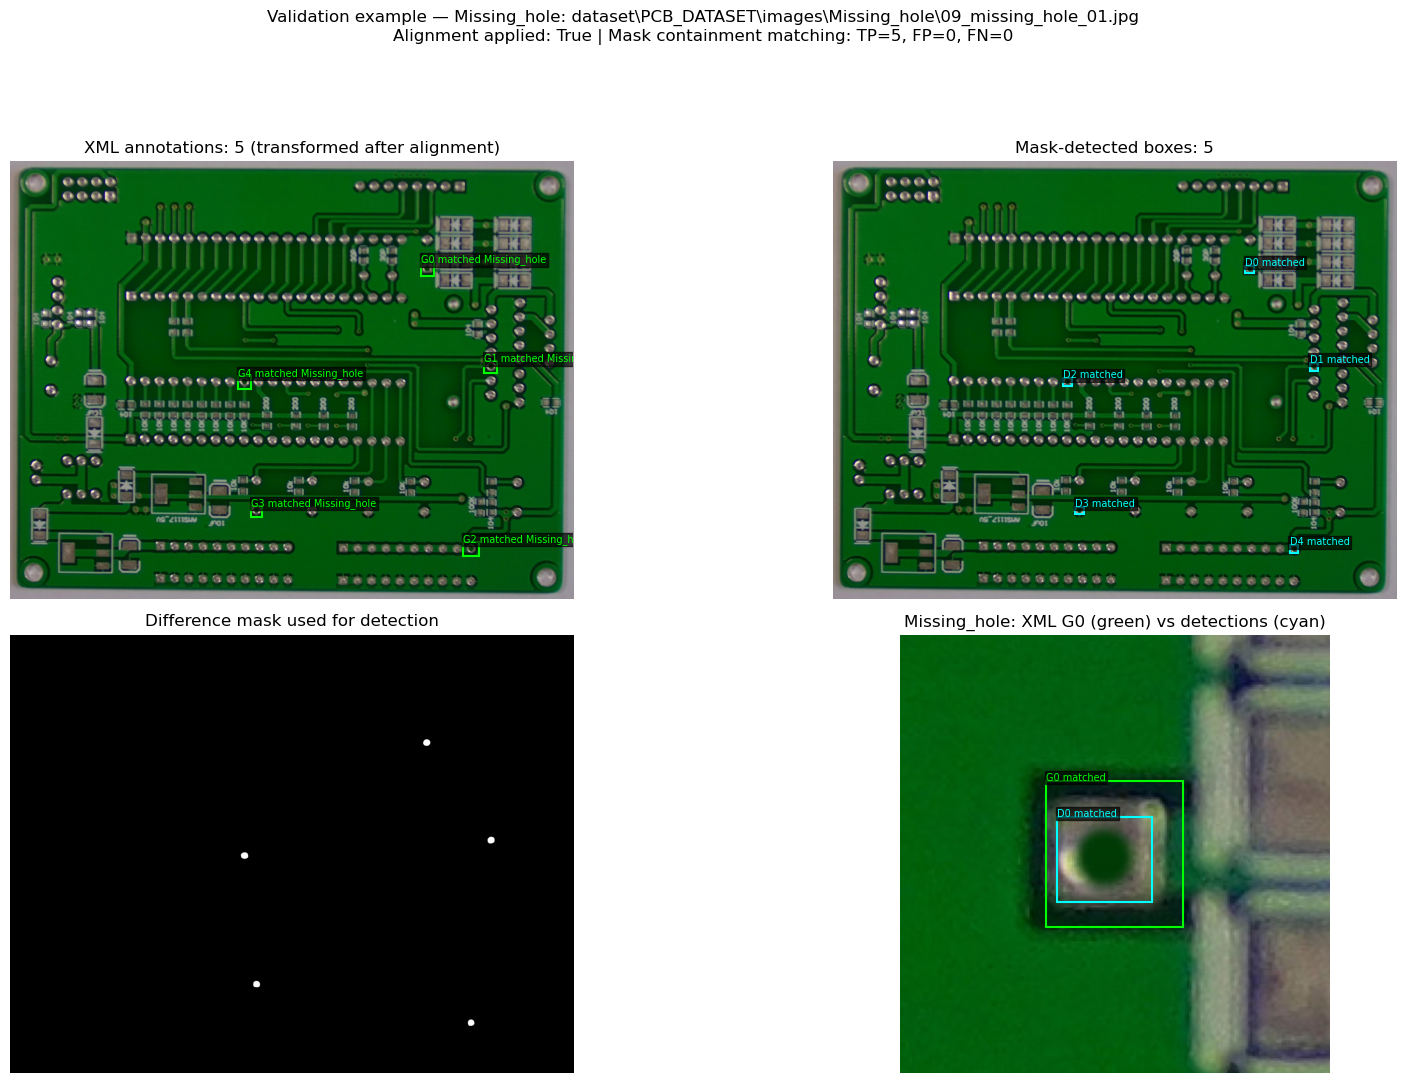

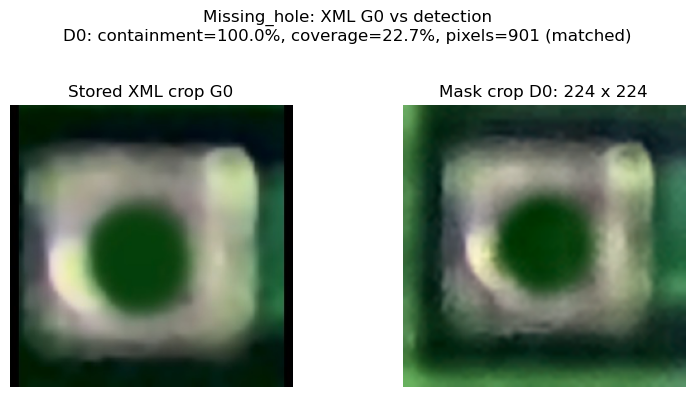

Matched region IDs and pixel metrics: [('D0', 'G0', {'intersection_pixels': 901.0, 'containment': 1.0, 'coverage': 0.22723833543505675}), ('D1', 'G1', {'intersection_pixels': 936.0, 'containment': 1.0, 'coverage': 0.2653061224489796}), ('D2', 'G4', {'intersection_pixels': 928.0, 'containment': 1.0, 'coverage': 0.22661782661782662}), ('D3', 'G3', {'intersection_pixels': 871.0, 'containment': 1.0, 'coverage': 0.30433263452131376}), ('D4', 'G2', {'intersection_pixels': 818.0, 'containment': 1.0, 'coverage': 0.15828173374613003})]


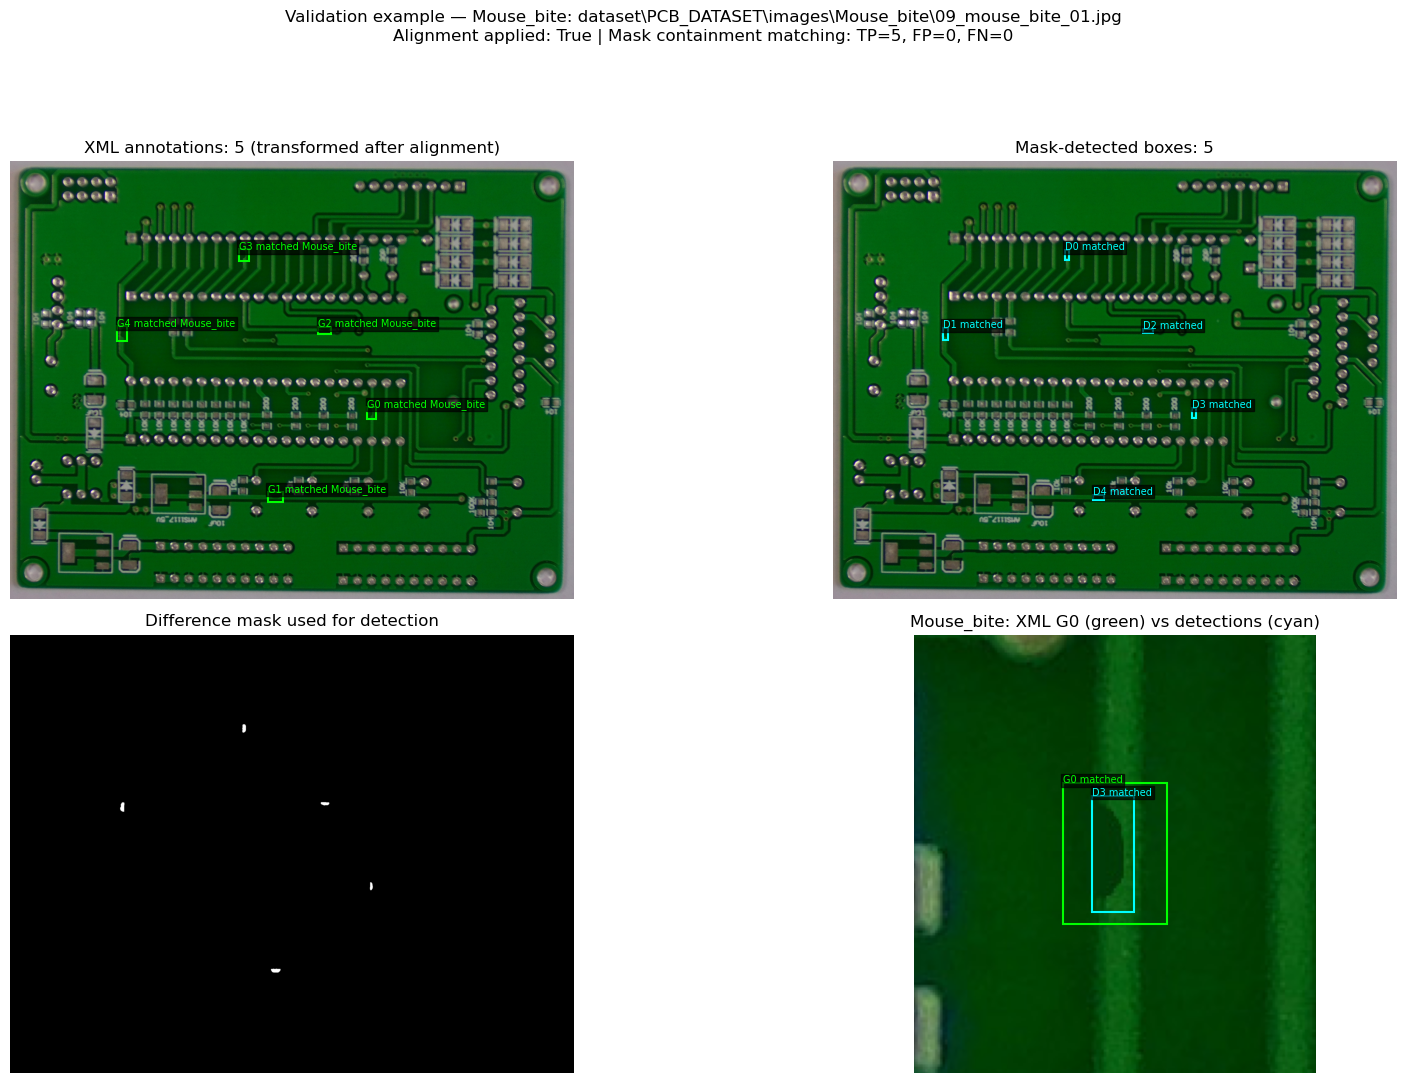

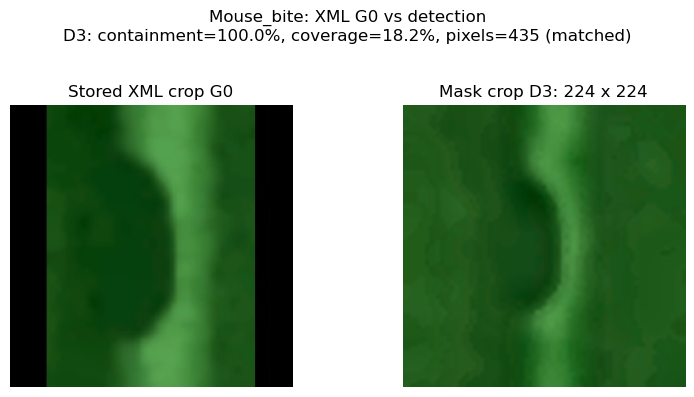

Matched region IDs and pixel metrics: [('D0', 'G3', {'intersection_pixels': 640.0, 'containment': 1.0, 'coverage': 0.22015823873409013}), ('D1', 'G4', {'intersection_pixels': 765.0, 'containment': 1.0, 'coverage': 0.2183219178082192}), ('D2', 'G2', {'intersection_pixels': 550.0, 'containment': 1.0, 'coverage': 0.22615131578947367}), ('D3', 'G0', {'intersection_pixels': 435.0, 'containment': 1.0, 'coverage': 0.18170426065162906}), ('D4', 'G1', {'intersection_pixels': 746.0, 'containment': 1.0, 'coverage': 0.2133867276887872})]


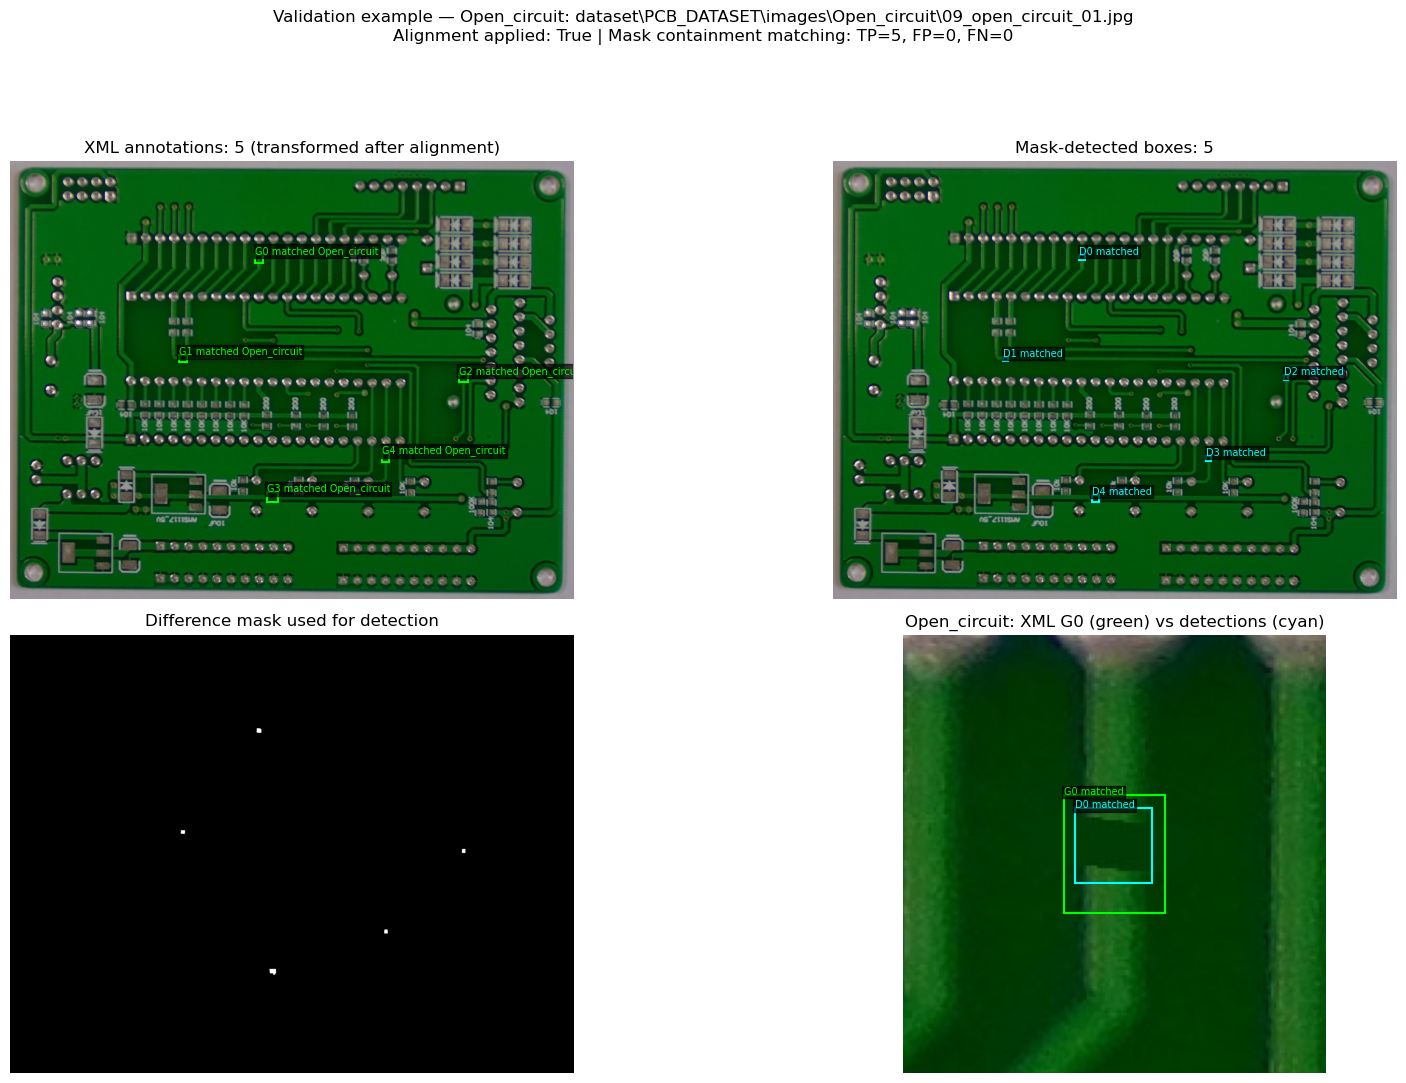

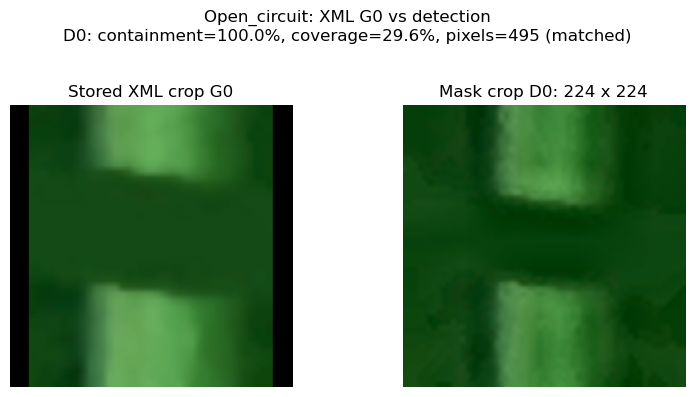

Matched region IDs and pixel metrics: [('D0', 'G0', {'intersection_pixels': 495.0, 'containment': 1.0, 'coverage': 0.29605263157894735}), ('D1', 'G1', {'intersection_pixels': 355.0, 'containment': 1.0, 'coverage': 0.23401450230718523}), ('D2', 'G2', {'intersection_pixels': 344.0, 'containment': 1.0, 'coverage': 0.19047619047619047}), ('D3', 'G4', {'intersection_pixels': 336.0, 'containment': 1.0, 'coverage': 0.2441860465116279}), ('D4', 'G3', {'intersection_pixels': 754.0, 'containment': 1.0, 'coverage': 0.24958622972525654})]


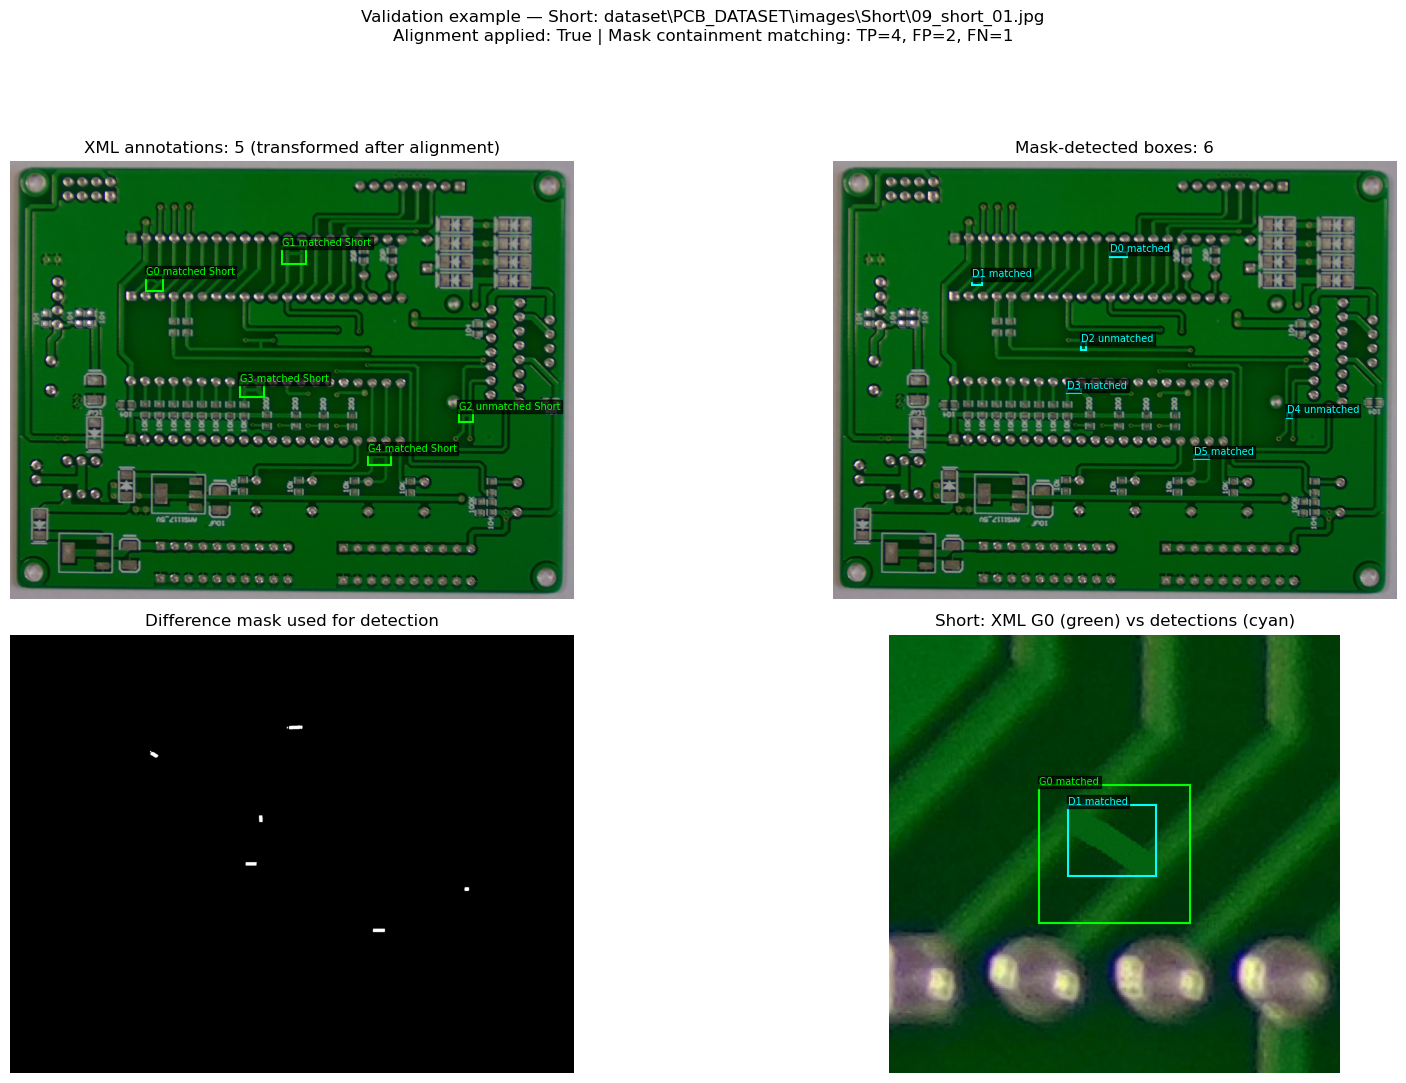

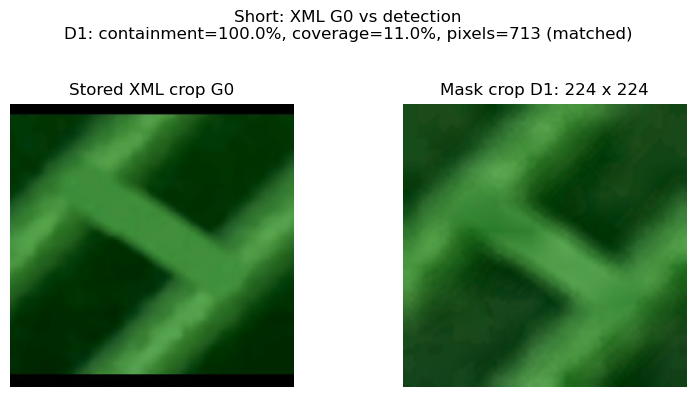

Matched region IDs and pixel metrics: [('D0', 'G1', {'intersection_pixels': 1128.0, 'containment': 1.0, 'coverage': 0.10895392639814547}), ('D1', 'G0', {'intersection_pixels': 713.0, 'containment': 1.0, 'coverage': 0.11023500309214596}), ('D3', 'G3', {'intersection_pixels': 915.0, 'containment': 1.0, 'coverage': 0.10252100840336134}), ('D5', 'G4', {'intersection_pixels': 1002.0, 'containment': 1.0, 'coverage': 0.13435237329042637})]


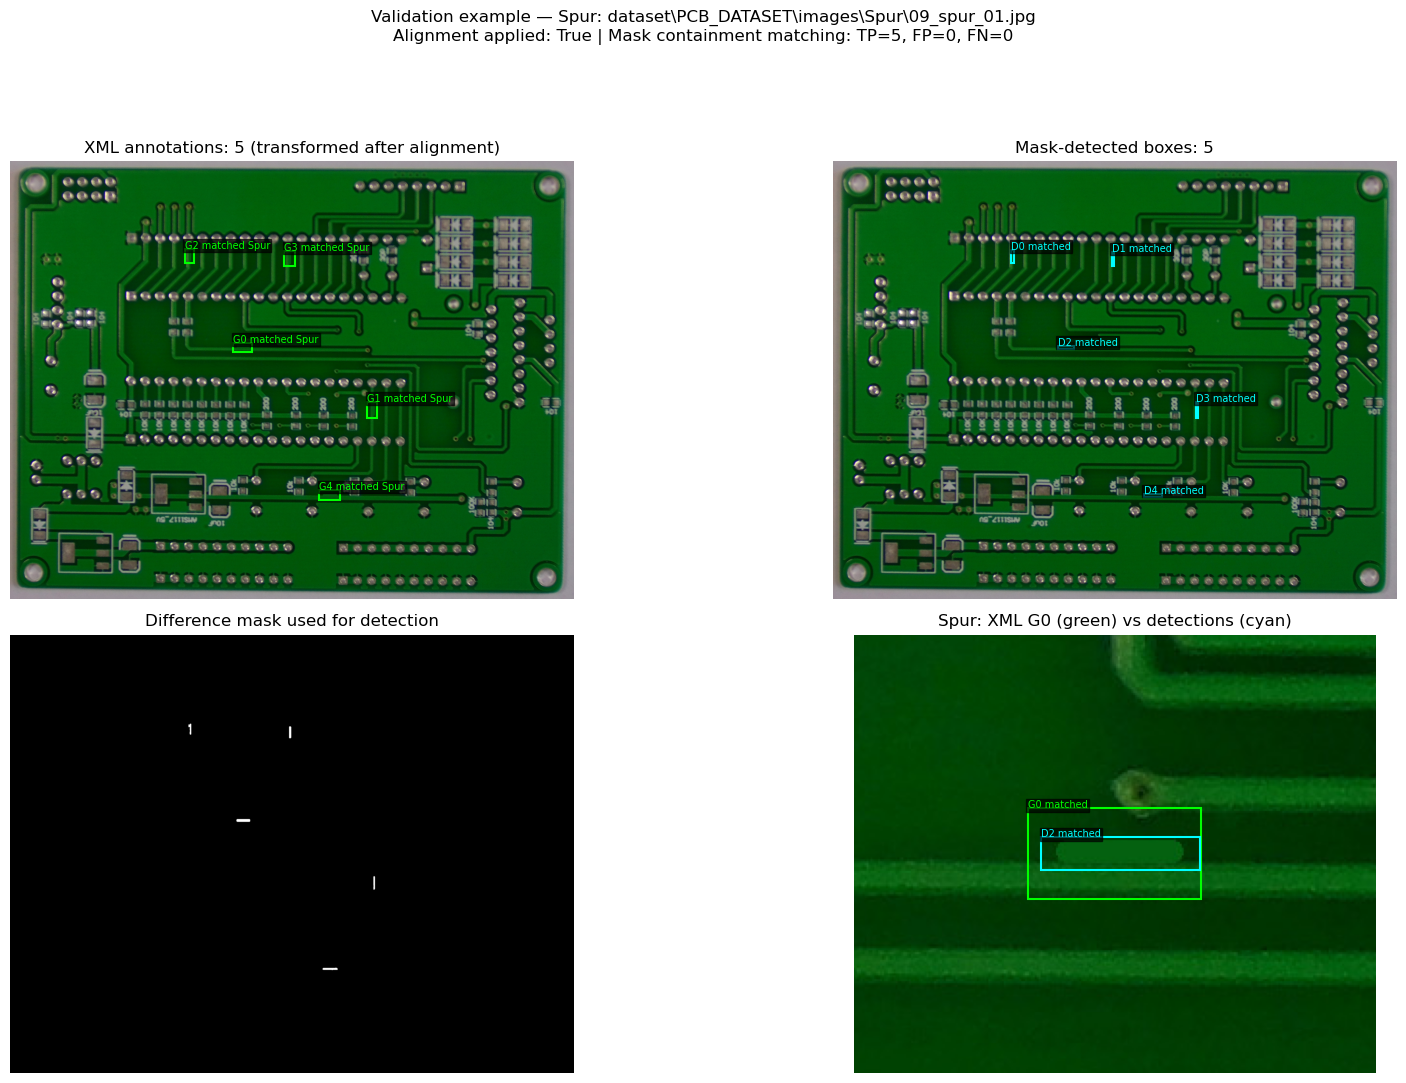

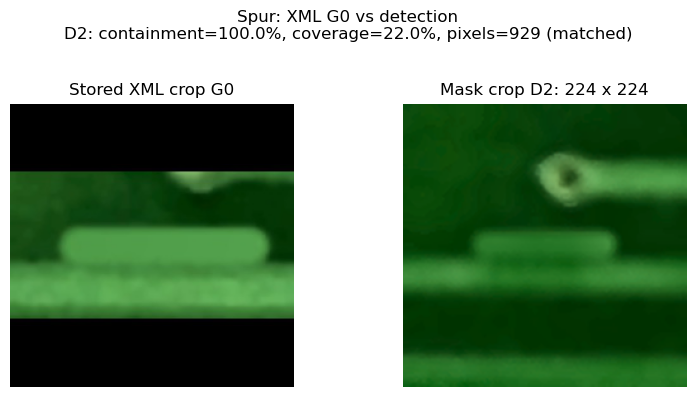

Matched region IDs and pixel metrics: [('D0', 'G2', {'intersection_pixels': 480.0, 'containment': 1.0, 'coverage': 0.15458937198067632}), ('D1', 'G3', {'intersection_pixels': 631.0, 'containment': 1.0, 'coverage': 0.16719660837307895}), ('D2', 'G0', {'intersection_pixels': 929.0, 'containment': 1.0, 'coverage': 0.21962174940898346}), ('D3', 'G1', {'intersection_pixels': 514.0, 'containment': 1.0, 'coverage': 0.1372863247863248}), ('D4', 'G4', {'intersection_pixels': 737.0, 'containment': 1.0, 'coverage': 0.15040816326530612})]


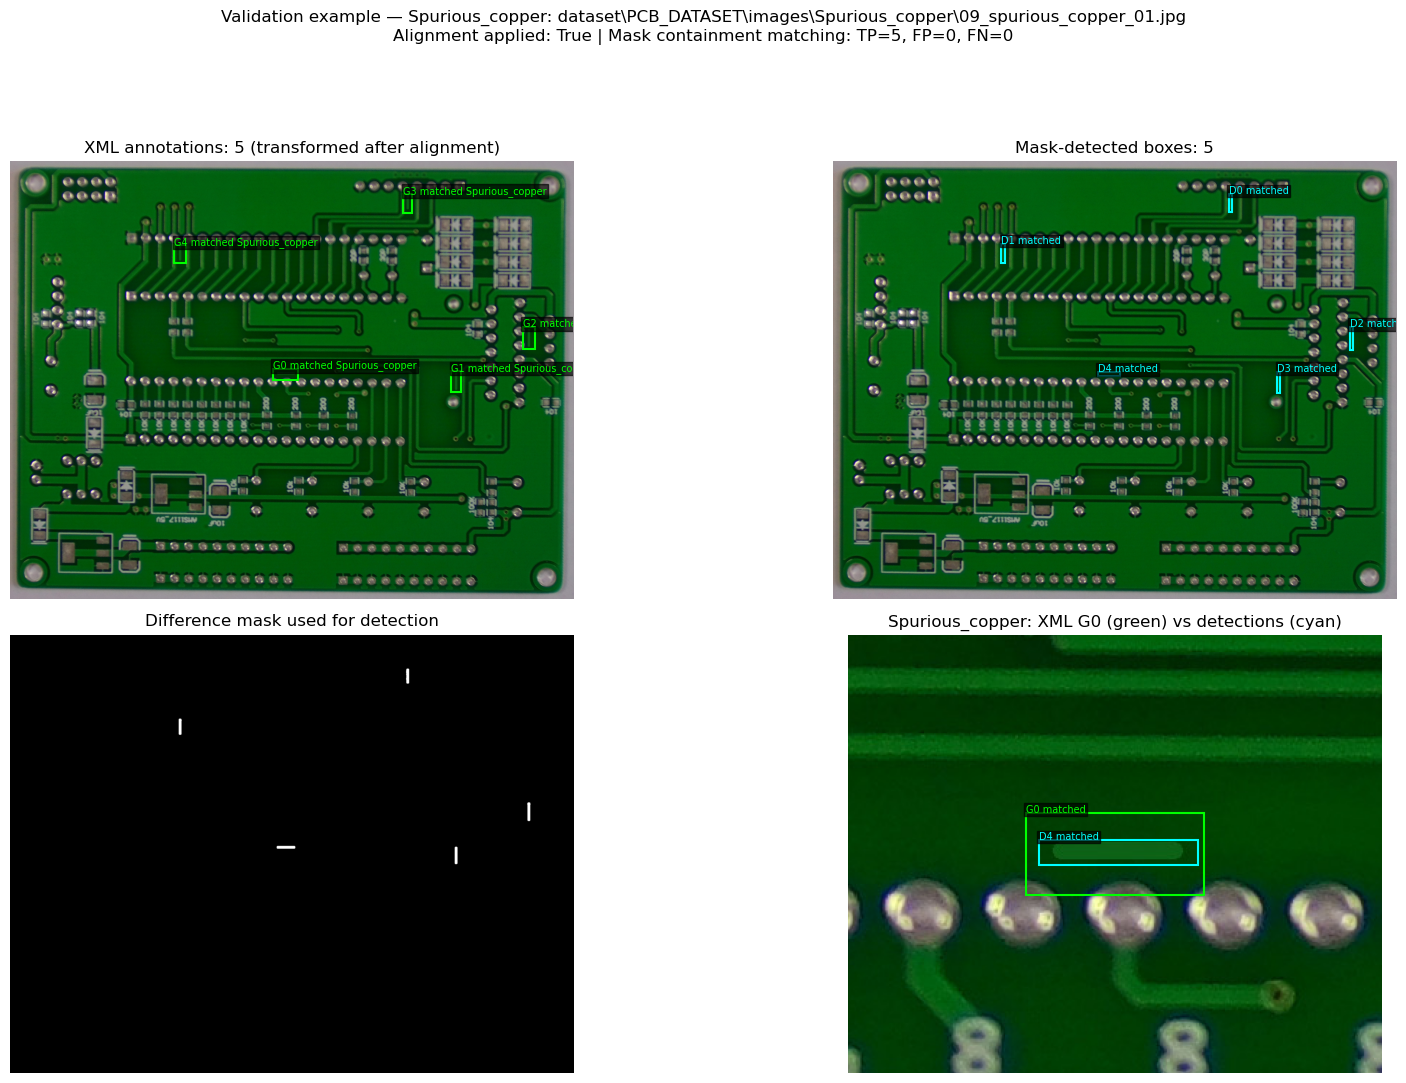

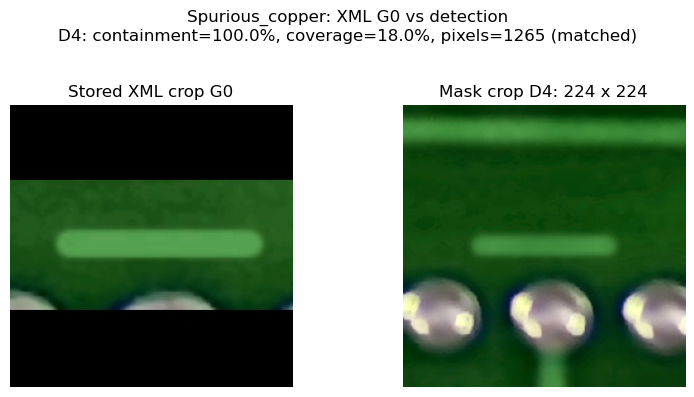

Matched region IDs and pixel metrics: [('D0', 'G3', {'intersection_pixels': 1044.0, 'containment': 1.0, 'coverage': 0.24461105904404873}), ('D1', 'G4', {'intersection_pixels': 1104.0, 'containment': 1.0, 'coverage': 0.21387059279349088}), ('D2', 'G2', {'intersection_pixels': 1281.0, 'containment': 1.0, 'coverage': 0.18284327719097915}), ('D3', 'G1', {'intersection_pixels': 1181.0, 'containment': 1.0, 'coverage': 0.22050037341299478}), ('D4', 'G0', {'intersection_pixels': 1265.0, 'containment': 1.0, 'coverage': 0.1804307516759378})]
val: completed AlexNet - Baseline
val: completed AlexNet - HPO-Tuned
val: completed CS-ResNet - Baseline
val: completed CS-ResNet - HPO-Tuned


C:\ProgramData\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


val: completed LPViT - Baseline
val: completed LPViT - HPO-Tuned
val: completed MobileNetV3 - Baseline
val: completed MobileNetV3 - HPO-Tuned


,model,evaluation,split,boards,detection_tp,detection_fp,detection_fn,detection_precision,detection_recall,detection_f1,accuracy,macro_f1,samples,class_micro_precision,class_micro_recall,class_micro_f1,matched_only_accuracy
0,Mask only,Mask localisation,val,92.0,429.0,44.0,38.0,0.906977,0.91863,0.912766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AlexNet - Baseline,XML crops,val,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.987152,0.986944,467.0,NaN,NaN,NaN,NaN
2,AlexNet - Baseline,Mask containment pipeline,val,92.0,429.0,44.0,38.0,0.906977,0.91863,0.912766,NaN,0.818903,NaN,0.813953,0.824411,0.819149,0.897436
3,AlexNet - HPO-Tuned,XML crops,val,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.978587,0.978482,467.0,NaN,NaN,NaN,NaN
4,AlexNet - HPO-Tuned,Mask containment pipeline,val,92.0,429.0,44.0,38.0,0.906977,0.91863,0.912766,NaN,0.844159,NaN,0.835095,0.845824,0.840426,0.920746
5,CS-ResNet - Baseline,XML crops,val,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.959315,0.959748,467.0,NaN,NaN,NaN,NaN
6,CS-ResNet - Baseline,Mask containment pipeline,val,92.0,429.0,44.0,38.0,0.906977,0.91863,0.912766,NaN,0.801267,NaN,0.786469,0.796574,0.791489,0.867133
7,CS-ResNet - HPO-Tuned,XML crops,val,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.976445,0.976106,467.0,NaN,NaN,NaN,NaN
8,CS-ResNet - HPO-Tuned,Mask containment pipeline,val,92.0,429.0,44.0,38.0,0.906977,0.91863,0.912766,NaN,0.824324,NaN,0.818182,0.828694,0.823404,0.902098
9,LPViT - Baseline,XML crops,val,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.768737,0.761991,467.0,NaN,NaN,NaN,NaN


In [66]:
# Validation only: use these results to select localisation settings.
validation_results = run_dual_evaluation('val')
display(validation_results)


In [67]:
# Final test: run only after freezing the validation configuration.
test_results = run_dual_evaluation('test')
display(test_results)


test: completed AlexNet - Baseline
test: completed AlexNet - HPO-Tuned
test: completed CS-ResNet - Baseline
test: completed CS-ResNet - HPO-Tuned


C:\ProgramData\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


test: completed LPViT - Baseline
test: completed LPViT - HPO-Tuned
test: completed MobileNetV3 - Baseline
test: completed MobileNetV3 - HPO-Tuned


,model,evaluation,split,boards,detection_tp,detection_fp,detection_fn,detection_precision,detection_recall,detection_f1,accuracy,macro_f1,samples,class_micro_precision,class_micro_recall,class_micro_f1,matched_only_accuracy
0,Mask only,Mask localisation,test,120.0,565.0,47.0,41.0,0.923203,0.932343,0.92775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AlexNet - Baseline,XML crops,test,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.967051,0.966791,607.0,NaN,NaN,NaN,NaN
2,AlexNet - Baseline,Mask containment pipeline,test,120.0,565.0,47.0,41.0,0.923203,0.932343,0.92775,NaN,0.801634,NaN,0.792484,0.800330,0.796388,0.858407
3,AlexNet - HPO-Tuned,XML crops,test,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.976936,0.976960,607.0,NaN,NaN,NaN,NaN
4,AlexNet - HPO-Tuned,Mask containment pipeline,test,120.0,565.0,47.0,41.0,0.923203,0.932343,0.92775,NaN,0.848057,NaN,0.839869,0.848185,0.844007,0.909735
5,CS-ResNet - Baseline,XML crops,test,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.975288,0.975278,607.0,NaN,NaN,NaN,NaN
6,CS-ResNet - Baseline,Mask containment pipeline,test,120.0,565.0,47.0,41.0,0.923203,0.932343,0.92775,NaN,0.789204,NaN,0.782680,0.790429,0.786535,0.847788
7,CS-ResNet - HPO-Tuned,XML crops,test,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.990115,0.990057,607.0,NaN,NaN,NaN,NaN
8,CS-ResNet - HPO-Tuned,Mask containment pipeline,test,120.0,565.0,47.0,41.0,0.923203,0.932343,0.92775,NaN,0.820133,NaN,0.818627,0.826733,0.822660,0.886726
9,LPViT - Baseline,XML crops,test,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.729819,0.723162,607.0,NaN,NaN,NaN,NaN
